In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 : ENVIRONMENT SETUP
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import time
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from xgboost import XGBRegressor

plt.rcParams.update({
    "figure.figsize"    : (14, 6),
    "axes.titlesize"    : 14,
    "axes.labelsize"    : 12,
    "font.size"         : 11,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

SEED = 42
np.random.seed(SEED)

print("✅  All libraries loaded")
print(f"📁  Working directory : {os.getcwd()}")
print(f"📄  Files here        : {[f for f in os.listdir('.') if not f.startswith('.') and f != 'venv']}")


✅  All libraries loaded
📁  Working directory : c:\Users\jaswa\Documents\internship project\compensiq
📄  Files here        : ['04_band_performance.png', 'app.py', 'artifacts', 'cat_cols.pkl', 'charts', 'compensiq.ipynb', 'employees_enhanced.csv', 'feature_columns.pkl', 'feature_importance.csv', 'model.pkl', 'model_metadata.json', 'report_arjun_sharma.pdf', 'report_james_wilson.pdf', 'report_priya_mehta.pdf', 'report_sarah_chen.pdf', 'requirements.txt', 'salaries.csv', 'scaler.pkl']


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 : LOAD DATA
# ═══════════════════════════════════════════════════════════════

df_raw = pd.read_csv("salaries.csv")

print(f"📂  Loaded : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\n📋  Columns ({df_raw.shape[1]}):")
for i, col in enumerate(df_raw.columns, 1):
    dtype  = str(df_raw[col].dtype)
    nuniq  = df_raw[col].nunique()
    sample = str(df_raw[col].iloc[0])
    print(f"    {i:>2}. {col:<28s} {dtype:<10s} {nuniq:>6} unique  |  sample: {sample}")

print(f"\n💰  Target — salary_in_usd:")
desc = df_raw["salary_in_usd"].describe()
for stat in ["count","mean","std","min","25%","50%","75%","max"]:
    val = desc[stat]
    if stat == "count":
        print(f"    {stat:<6s}: {val:>12,.0f}")
    else:
        print(f"    {stat:<6s}: ${val:>12,.0f}")

print(f"\n📊  Key Column Distributions:")
for col in ["experience_level","company_size","company_tier",
            "education_level","industry","city_tier"]:
    print(f"\n    {col}:")
    for val, cnt in df_raw[col].value_counts().items():
        pct = cnt / len(df_raw) * 100
        bar = "█" * int(pct / 3)
        print(f"      {str(val):<16s} {cnt:>6,}  ({pct:>5.1f}%)  {bar}")

df_raw.head()

📂  Loaded : 50,000 rows × 15 columns

📋  Columns (15):
     1. work_year                    int64           7 unique  |  sample: 2025
     2. experience_level             object          4 unique  |  sample: MI
     3. employment_type              object          4 unique  |  sample: FT
     4. job_title                    object         47 unique  |  sample: Analytics Manager
     5. job_family                   object          7 unique  |  sample: Manager
     6. salary_in_usd                int64       45021 unique  |  sample: 297491
     7. employee_residence           object         20 unique  |  sample: US
     8. remote_ratio                 int64          13 unique  |  sample: 0
     9. company_location             object         20 unique  |  sample: US
    10. company_size                 object          3 unique  |  sample: L
    11. company_tier                 object          4 unique  |  sample: Big Tech
    12. education_level              object          4 unique  |  sa

,work_year,experience_level,employment_type,job_title,job_family,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_tier,education_level,years_of_experience,industry,city_tier
0,2025,MI,FT,Analytics Manager,Manager,297491,US,0,US,L,Big Tech,Bachelor,5,Tech,Tier1_Metro
1,2023,SE,FT,Data Scientist,Data Scientist,222232,US,0,US,L,Enterprise,Master,7,Tech,Tier2_City
2,2026,SE,FT,Business Intelligence Engineer,Analyst,138352,US,90,US,M,Mid-tier,Bachelor,11,Tech,Tier1_Metro
3,2025,EX,FT,Applied Scientist,Data Scientist,46431,IN,100,IN,M,Mid-tier,PhD,16,Tech,International
4,2024,SE,FT,BI Analyst,Analyst,160872,US,60,US,M,Mid-tier,Master,10,Tech,Tier2_City


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 : DATA QUALITY REPORT
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  DATA QUALITY REPORT")
print("=" * 70)

# ── Missing values ────────────────────────────────────────────
print("\n🔍  Missing Values:")
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print("    ✅  No missing values found")
else:
    print(missing[missing > 0])

# ── Duplicates ────────────────────────────────────────────────
dupes = df_raw.duplicated().sum()
print(f"\n🔍  Duplicate Rows : {dupes:,}",
      "✅" if dupes == 0 else "⚠️  Will be removed")

# ── Salary outliers ───────────────────────────────────────────
print("\n💰  Salary Distribution Check:")
print(f"    Below $30k   : {(df_raw['salary_in_usd'] < 30000).sum():>6,} rows")
print(f"    $30k–$50k    : {((df_raw['salary_in_usd']>=30000)&(df_raw['salary_in_usd']<50000)).sum():>6,} rows")
print(f"    $50k–$300k   : {((df_raw['salary_in_usd']>=50000)&(df_raw['salary_in_usd']<=300000)).sum():>6,} rows  ← healthy range")
print(f"    $300k–$500k  : {((df_raw['salary_in_usd']>300000)&(df_raw['salary_in_usd']<=500000)).sum():>6,} rows")
print(f"    Above $500k  : {(df_raw['salary_in_usd']>500000).sum():>6,} rows  ← will be capped")

# ── Company size balance ──────────────────────────────────────
print("\n🏢  Company Size Balance:")
size_labels = {"S":"Small  ","M":"Medium ","L":"Large  "}
for sz in ["S","M","L"]:
    n   = (df_raw["company_size"] == sz).sum()
    pct = n / len(df_raw) * 100
    bar = "█" * int(pct / 2)
    print(f"    {size_labels[sz]}  {n:>6,}  ({pct:>5.1f}%)  {bar}")

# ── Experience balance ────────────────────────────────────────
print("\n📊  Experience Level Balance:")
for lvl in ["EN","MI","SE","EX"]:
    n   = (df_raw["experience_level"] == lvl).sum()
    pct = n / len(df_raw) * 100
    bar = "█" * int(pct / 2)
    print(f"    {lvl}  {n:>6,}  ({pct:>5.1f}%)  {bar}")

# ── Remote ratio ──────────────────────────────────────────────
print("\n🏠  Remote Ratio Values:")
for val in sorted(df_raw["remote_ratio"].unique()):
    n   = (df_raw["remote_ratio"] == val).sum()
    pct = n / len(df_raw) * 100
    print(f"    {val:>3}%  :  {n:>5,}  ({pct:>5.1f}%)")

# ── Salary by key groups ──────────────────────────────────────
print("\n📈  Median Salary by Experience Level:")
for lvl in ["EN","MI","SE","EX"]:
    med = df_raw[df_raw["experience_level"]==lvl]["salary_in_usd"].median()
    print(f"    {lvl}  →  ${med:>9,.0f}")

print("\n📈  Median Salary by Company Size:")
for sz in ["S","M","L"]:
    med = df_raw[df_raw["company_size"]==sz]["salary_in_usd"].median()
    print(f"    {size_labels[sz]}  →  ${med:>9,.0f}")

print("\n📈  Median Salary by Company Tier:")
for tier in ["Startup","Mid-tier","Enterprise","Big Tech"]:
    med = df_raw[df_raw["company_tier"]==tier]["salary_in_usd"].median()
    print(f"    {tier:<12s}  →  ${med:>9,.0f}")

print("\n📈  Median Salary by Education:")
for edu in ["Bachelor","Master","PhD","MBA"]:
    med = df_raw[df_raw["education_level"]==edu]["salary_in_usd"].median()
    print(f"    {edu:<10s}  →  ${med:>9,.0f}")

print("\n📈  Median Salary by Remote Ratio:")
for val in [0, 25, 50, 75, 100]:
    sub = df_raw[df_raw["remote_ratio"]==val]
    if len(sub) > 0:
        med = sub["salary_in_usd"].median()
        print(f"    {val:>3}%  →  ${med:>9,.0f}  ({len(sub):,} rows)")

print("\n📈  Median Salary by Country (top 8):")
for country in ["US","CA","GB","DE","IN","AU","SG","BR"]:
    sub = df_raw[df_raw["company_location"]==country]
    if len(sub) > 0:
        med = sub["salary_in_usd"].median()
        print(f"    {country}  →  ${med:>9,.0f}  ({len(sub):,} rows)")

print(f"\n{'='*70}")
print(f"  REPORT COMPLETE — dataset is clean and ready")
print(f"{'='*70}")

  DATA QUALITY REPORT

🔍  Missing Values:
    ✅  No missing values found

🔍  Duplicate Rows : 1 ⚠️  Will be removed

💰  Salary Distribution Check:
    Below $30k   :  2,376 rows
    $30k–$50k    :  4,914 rows
    $50k–$300k   : 41,735 rows  ← healthy range
    $300k–$500k  :    971 rows
    Above $500k  :      4 rows  ← will be capped

🏢  Company Size Balance:
    Small     7,483  ( 15.0%)  ███████
    Medium   27,473  ( 54.9%)  ███████████████████████████
    Large    15,044  ( 30.1%)  ███████████████

📊  Experience Level Balance:
    EN   7,533  ( 15.1%)  ███████
    MI  15,049  ( 30.1%)  ███████████████
    SE  19,961  ( 39.9%)  ███████████████████
    EX   7,457  ( 14.9%)  ███████

🏠  Remote Ratio Values:
      0%  :  14,976  ( 30.0%)
     10%  :  1,496  (  3.0%)
     20%  :  1,531  (  3.1%)
     25%  :  2,031  (  4.1%)
     30%  :  2,364  (  4.7%)
     40%  :  2,081  (  4.2%)
     50%  :  4,019  (  8.0%)
     60%  :  1,986  (  4.0%)
     70%  :  2,043  (  4.1%)
     75%  :  2,477 

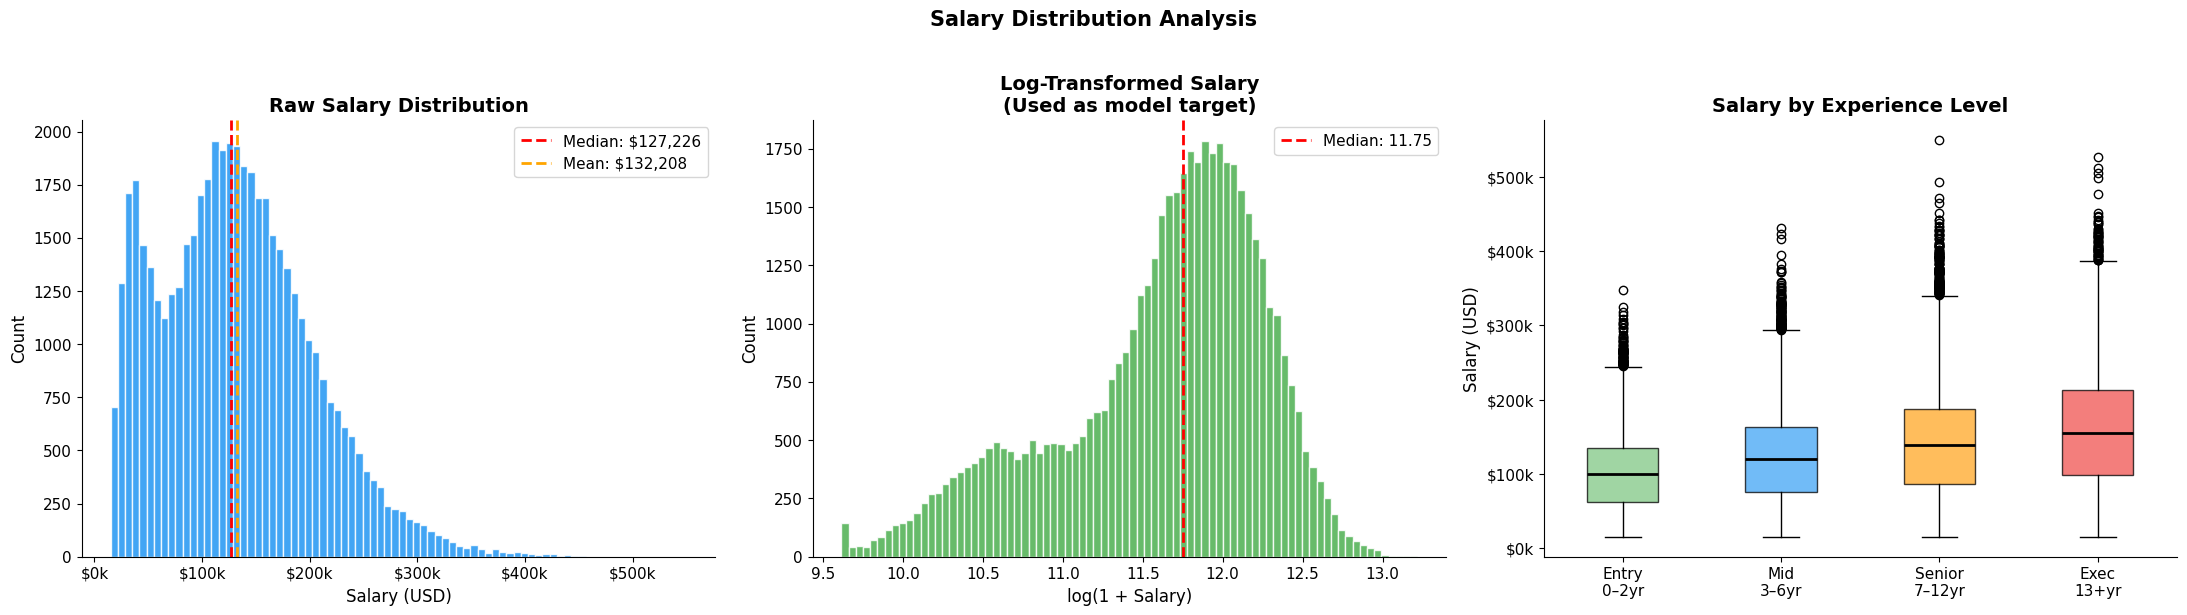

📊  Skewness Analysis:
    Raw salary  — Skewness : 0.614
    Raw salary  — Kurtosis : 0.391
    Log salary  — Skewness : -0.776
    Log salary  — Kurtosis : 0.047

💡  Why log transform:
    Raw skewness 0.61 → right skewed
    Log skewness -0.78 → near normal
    Errors become proportional not absolute.

✅  Saved: 01_target_distribution.png


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 : TARGET DISTRIBUTION ANALYSIS
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── Plot 1: Raw salary distribution ──────────────────────────
axes[0].hist(df_raw["salary_in_usd"], bins=80,
             color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].axvline(df_raw["salary_in_usd"].median(), color="red",
                linestyle="--", lw=2,
                label=f'Median: ${df_raw["salary_in_usd"].median():,.0f}')
axes[0].axvline(df_raw["salary_in_usd"].mean(), color="orange",
                linestyle="--", lw=2,
                label=f'Mean: ${df_raw["salary_in_usd"].mean():,.0f}')
axes[0].set_title("Raw Salary Distribution", weight="bold")
axes[0].set_xlabel("Salary (USD)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].legend()

# ── Plot 2: Log-transformed ───────────────────────────────────
log_sal = np.log1p(df_raw["salary_in_usd"])
axes[1].hist(log_sal, bins=80,
             color="#4CAF50", edgecolor="white", alpha=0.85)
axes[1].axvline(log_sal.median(), color="red", linestyle="--", lw=2,
                label=f'Median: {log_sal.median():.2f}')
axes[1].set_title("Log-Transformed Salary\n(Used as model target)",
                  weight="bold")
axes[1].set_xlabel("log(1 + Salary)")
axes[1].set_ylabel("Count")
axes[1].legend()

# ── Plot 3: Salary by experience level ───────────────────────
order  = ["EN","MI","SE","EX"]
labels = {"EN":"Entry\n0–2yr","MI":"Mid\n3–6yr",
          "SE":"Senior\n7–12yr","EX":"Exec\n13+yr"}
colors = ["#81C784","#42A5F5","#FFA726","#EF5350"]
data   = [df_raw[df_raw["experience_level"]==lvl]["salary_in_usd"].values
          for lvl in order]

bp = axes[2].boxplot(data, labels=[labels[l] for l in order],
                     patch_artist=True,
                     medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[2].set_title("Salary by Experience Level", weight="bold")
axes[2].set_ylabel("Salary (USD)")
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.suptitle("Salary Distribution Analysis",
             fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊  Skewness Analysis:")
print(f"    Raw salary  — Skewness : {df_raw['salary_in_usd'].skew():.3f}")
print(f"    Raw salary  — Kurtosis : {df_raw['salary_in_usd'].kurtosis():.3f}")
print(f"    Log salary  — Skewness : {log_sal.skew():.3f}")
print(f"    Log salary  — Kurtosis : {log_sal.kurtosis():.3f}")
print()
print("💡  Why log transform:")
print(f"    Raw skewness {df_raw['salary_in_usd'].skew():.2f} → right skewed")
print(f"    Log skewness {log_sal.skew():.2f} → near normal")
print("    Errors become proportional not absolute.")
print()
print("✅  Saved: 01_target_distribution.png")

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 : DATA CLEANING
# ═══════════════════════════════════════════════════════════════

df = df_raw.copy()

print("=" * 70)
print("  DATA CLEANING PIPELINE")
print("=" * 70)
print(f"\n  Starting : {len(df):,} rows × {df.shape[1]} columns")

# ── STEP 1: Remove duplicate rows ────────────────────────────
print(f"\n{'─'*70}")
print(f"  STEP 1 — Remove duplicates")
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Removed : {before - len(df):,} duplicate rows")
print(f"  Remaining : {len(df):,} rows")

# ── STEP 2: Drop redundant columns ───────────────────────────
print(f"\n{'─'*70}")
print(f"  STEP 2 — Drop redundant columns")
drop_cols = ["employment_type"]
df.drop(columns=drop_cols, errors="ignore", inplace=True)
print(f"  Dropped : {drop_cols}")
print(f"  Reason  : 92% Full-time — near zero variance, adds no signal")

# ── STEP 3: Cap salary outliers ──────────────────────────────
print(f"\n{'─'*70}")
print(f"  STEP 3 — Salary outlier capping")
cap_lo = df["salary_in_usd"].quantile(0.01)
cap_hi = 500_000
before = len(df)
below  = (df["salary_in_usd"] < cap_lo).sum()
above  = (df["salary_in_usd"] > cap_hi).sum()
print(f"  Bottom 1% threshold : ${cap_lo:,.0f}")
print(f"  Rows below ${cap_lo:,.0f} : {below:,}")
print(f"  Rows above $500,000 : {above:,}")
df = df[(df["salary_in_usd"] >= cap_lo) &
        (df["salary_in_usd"] <= cap_hi)].copy()
df.reset_index(drop=True, inplace=True)
print(f"  Removed : {before - len(df):,} rows")
print(f"  Remaining : {len(df):,} rows")
print(f"  Range : ${df['salary_in_usd'].min():,.0f} – "
      f"${df['salary_in_usd'].max():,.0f}")

# ── STEP 4: Keep all industry categories as-is ───────────────
# Industries: Tech, Finance, Research, Consulting, Retail
# All have distinct salary profiles — no merging, no renaming
print(f"\n{'─'*70}")
print(f"  STEP 4 — Industry categories (kept as-is, no merging)")
tech_med = df[df["industry"]=="Tech"]["salary_in_usd"].median()
for ind, cnt in df["industry"].value_counts().items():
    med  = df[df["industry"]==ind]["salary_in_usd"].median()
    mult = med / tech_med
    print(f"    {ind:<16s} : {cnt:>6,} rows  median ${med:>9,.0f}  x{mult:.3f} vs Tech")

# ── STEP 5: Verify salary ladders still hold ─────────────────
print(f"\n{'─'*70}")
print(f"  STEP 5 — Verify salary ladders after cleaning")

print(f"\n  Experience Level:")
for lvl in ["EN","MI","SE","EX"]:
    med = df[df["experience_level"]==lvl]["salary_in_usd"].median()
    print(f"    {lvl}  →  ${med:>9,.0f}")

print(f"\n  Company Size:")
size_labels = {"S":"Small  ","M":"Medium ","L":"Large  "}
for sz in ["S","M","L"]:
    med = df[df["company_size"]==sz]["salary_in_usd"].median()
    print(f"    {size_labels[sz]}  →  ${med:>9,.0f}")

print(f"\n  Company Tier:")
for tier in ["Startup","Mid-tier","Enterprise","Big Tech"]:
    med = df[df["company_tier"]==tier]["salary_in_usd"].median()
    print(f"    {tier:<12s}  →  ${med:>9,.0f}")

print(f"\n{'='*70}")
print(f"  CLEANING COMPLETE")
print(f"  Final shape : {len(df):,} rows × {df.shape[1]} columns")
print(f"  Columns     : {list(df.columns)}")
print(f"{'='*70}")


  DATA CLEANING PIPELINE

  Starting : 50,000 rows × 15 columns

──────────────────────────────────────────────────────────────────────
  STEP 1 — Remove duplicates
  Removed : 1 duplicate rows
  Remaining : 49,999 rows

──────────────────────────────────────────────────────────────────────
  STEP 2 — Drop redundant columns
  Dropped : ['employment_type']
  Reason  : 92% Full-time — near zero variance, adds no signal

──────────────────────────────────────────────────────────────────────
  STEP 3 — Salary outlier capping
  Bottom 1% threshold : $20,250
  Rows below $20,250 : 500
  Rows above $500,000 : 4
  Removed : 504 rows
  Remaining : 49,495 rows
  Range : $20,250 – $497,874

──────────────────────────────────────────────────────────────────────
  STEP 4 — Industry categories (kept as-is, no merging)
    Tech             : 44,322 rows  median $  127,099  x1.000 vs Tech
    Finance          :  2,306 rows  median $  145,958  x1.148 vs Tech
    Research         :  1,666 rows  median $

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 : FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════
 
print("=" * 70)
print("  FEATURE ENGINEERING")
print("=" * 70)
 
# ── FEATURE 1: seniority_flag ────────────────────────────────
SNR = r"(?i)(senior|lead|principal|staff|head|chief|distinguished|fellow|vp |director)"
df["seniority_flag"] = df["job_title"].str.contains(
    SNR, regex=True).astype(int)
 
print(f"\n✅  FEATURE 1 — seniority_flag")
print(f"    Senior titles    : {df['seniority_flag'].sum():,} "
      f"({df['seniority_flag'].mean()*100:.1f}%)")
for flag, label in [(1,"Senior title"),(0,"Non-senior title")]:
    med = df[df["seniority_flag"]==flag]["salary_in_usd"].median()
    print(f"    {label:<20s} → median ${med:,.0f}")
 
# ── FEATURE 2: geography ─────────────────────────────────────
REGION_MAP = {
    "US":"North America","CA":"North America","MX":"North America",
    "GB":"Europe_West","DE":"Europe_West","FR":"Europe_West",
    "NL":"Europe_West","IE":"Europe_West","AT":"Europe_West",
    "BE":"Europe_West","PT":"Europe_South","ES":"Europe_South",
    "PL":"Europe_East","LT":"Europe_East","LV":"Europe_East",
    "SK":"Europe_East","IN":"Asia_Em","AU":"Asia_Dev",
    "SG":"Asia_Dev","BR":"LatAm","ZA":"Africa","AR":"LatAm",
}
 
COUNTRY_GEO = {
    "US":1.000,"CA":0.780,"GB":0.700,"DE":0.680,"FR":0.600,
    "NL":0.730,"IE":0.750,"AT":0.640,"BE":0.620,"MX":0.290,
    "PL":0.320,"LT":0.240,"LV":0.240,"SK":0.280,"ES":0.460,
    "PT":0.380,"IN":0.180,"AU":0.740,"BR":0.250,"ZA":0.250,
    "AR":0.180,"SG":0.680,
}
 
REGION_FALLBACK = {
    "North America":0.820,"Europe_West":0.660,"Europe_South":0.420,
    "Europe_East":0.270,"Asia_Dev":0.570,"Asia_Em":0.220,
    "LatAm":0.230,"Africa":0.170,"Other":0.300,
}
 
df["company_region"]  = df["company_location"].map(REGION_MAP).fillna("Other")
df["employee_region"] = df["employee_residence"].map(REGION_MAP).fillna("Other")
df["is_us"]           = (df["company_location"] == "US").astype(int)
df["geo_multiplier"]  = df.apply(
    lambda r: COUNTRY_GEO.get(
        r["company_location"],
        REGION_FALLBACK.get(r["company_region"], 0.300)
    ), axis=1
)
 
print(f"\n✅  FEATURE 2 — geography")
print(f"    is_us : {df['is_us'].mean()*100:.1f}% US companies")
for country in ["US","CA","GB","DE","IN","AU","SG","BR"]:
    sub = df[df["company_location"]==country]
    if len(sub) > 0:
        geo = COUNTRY_GEO.get(country, 0.3)
        med = sub["salary_in_usd"].median()
        print(f"    {country} → geo×{geo:.2f}  "
              f"median ${med:,.0f}  ({len(sub):,} rows)")
 
# ── FEATURE 3: remote_type ───────────────────────────────────
def classify_remote(row):
    cross = (row["company_location"] != row["employee_residence"])
    if row["remote_ratio"] >= 80:
        return "global_remote" if cross else "remote"
    elif row["remote_ratio"] >= 30:
        return "hybrid"
    return "onsite"
 
df["remote_type"]     = df.apply(classify_remote, axis=1)
df["remote_fraction"] = df["remote_ratio"] / 100.0
 
print(f"\n✅  FEATURE 3 — remote_type")
for rt in ["onsite","hybrid","remote","global_remote"]:
    n   = (df["remote_type"] == rt).sum()
    med = df[df["remote_type"]==rt]["salary_in_usd"].median()
    print(f"    {rt:<14s} : {n:>6,} rows  median ${med:,.0f}")
 
# ── FEATURE 4: market_cycle ──────────────────────────────────
MARKET_CYCLE = {
    2020:0.91, 2021:0.94, 2022:1.06,
    2023:1.09, 2024:1.00, 2025:0.98, 2026:1.01
}
df["years_since_2020"] = df["work_year"] - 2020
df["market_cycle"]     = df["work_year"].map(MARKET_CYCLE).fillna(1.00)
df["is_2026"]          = (df["work_year"] == 2026).astype(int)
 
print(f"\n✅  FEATURE 4 — market_cycle")
for yr, cyc in MARKET_CYCLE.items():
    n   = (df["work_year"] == yr).sum()
    tag = " ← boom" if cyc > 1.05 else \
          " ← correction" if cyc < 0.99 else ""
    print(f"    {yr} → ×{cyc:.2f}  {n:,} rows{tag}")
 
# ── FEATURE 5: economic signal ───────────────────────────────
 
# Base salary per job title — dataset median (all 47 titles)
BASE_SALARY = {
    # Analyst family
    "Business Intelligence Engineer": 97290,
    "BI Analyst":                      96803,
    "Analytics Analyst":               98150,
    "Product Analyst":                 98066,
    "Reporting Analyst":               100853,
    "Data Analyst":                    94054,
    "Business Analyst":                98067,
    # Architect family
    "ML Architect":                    146828,
    "Enterprise Architect":            146196,
    "Solution Architect":              150416,
    "Data Architect":                  144830,
    "Cloud Architect":                 144586,
    # Data Engineer family
    "Data Platform Engineer":          127872,
    "Analytics Engineer":              128539,
    "Data Engineer":                   131379,
    "Software Engineer":               128373,
    "Backend Engineer":                128418,
    "Senior Data Engineer":            128486,
    "Cloud Data Engineer":             127474,
    "ETL Engineer":                    127291,
    # Data Scientist family
    "Data Scientist":                  135572,
    "Applied Scientist":               137006,
    "Data Science Lead":               130138,
    "Senior Data Scientist":           134070,
    "Research Scientist":              144150,
    "Quantitative Researcher":         162888,
    # ML Engineer family
    "MLOps Engineer":                  146748,
    "Deep Learning Engineer":          146953,
    "Senior ML Engineer":              149422,
    "AI Engineer":                     149496,
    "ML Engineer":                     148298,
    "Machine Learning Engineer":       150466,
    "Applied ML Engineer":             150444,
    "NLP Engineer":                    147238,
    # Manager family
    "Analytics Manager":               158985,
    "VP of Analytics":                 150167,
    "Data Science Manager":            159623,
    "Director of Data Science":        157182,
    "Head of Data":                    159942,
    "Chief Data Officer":              160885,
    "Engineering Manager":             167991,
    "Data Manager":                    164516,
    # Other family — Consultants & Specialists
    "Data Consultant":                 109546,
    "Data Specialist":                 101486,
    "AI Consultant":                   113714,
    "Data Product Manager":            114326,
    "Research Analyst":                107849,
}
 
TIER_MULT = {
    "Startup":0.82, "Mid-tier":1.00,
    "Enterprise":1.12, "Big Tech":1.45,
}
EDU_MULT = {
    "Bachelor":1.00, "Master":1.08, "PhD":1.18, "MBA":1.10,
}
# Industry multipliers derived from actual dataset medians vs Tech median
# Tech:$126,164 | Finance:$145,680(x1.155) | Research:$144,150(x1.143)
# Consulting:$123,538(x0.979) | Retail:$83,864(x0.665)
INDUSTRY_MULT = {
    "Finance":    1.155,
    "Research":   1.143,
    "Tech":       1.000,
    "Consulting": 0.979,
    "Retail":     0.665,
}
REMOTE_MULT = {
    0:1.02, 10:1.01, 20:1.01, 25:1.00, 30:1.00,
    40:0.99, 50:0.99, 60:0.98, 70:0.97,
    75:0.97, 80:0.96, 90:0.96, 100:0.95,
}
 
def exp_multiplier(years):
    mult = 1.0
    for yr in range(1, int(years)+1):
        if yr <= 2:    mult *= 1.060
        elif yr <= 5:  mult *= 1.045
        elif yr <= 8:  mult *= 1.030
        elif yr <= 12: mult *= 1.018
        else:          mult *= 1.010
    return mult
 
# KEY: map base salary per job_title not job_family
df["base_salary_index"]     = df["job_title"].map(BASE_SALARY)
df["company_multiplier"]    = df["company_tier"].map(TIER_MULT)
df["edu_multiplier"]        = df["education_level"].map(EDU_MULT)
df["industry_multiplier"]   = df["industry"].map(INDUSTRY_MULT)
df["remote_multiplier"]     = df["remote_ratio"].map(REMOTE_MULT).fillna(0.97)
df["experience_multiplier"] = df["years_of_experience"].apply(exp_multiplier)
df["skills_multiplier"]     = 1.0 + (df["years_of_experience"] * 0.006)
 
df["expected_salary_signal"] = (
    df["base_salary_index"]
    * df["experience_multiplier"]
    * df["company_multiplier"]
    * df["geo_multiplier"]
    * df["edu_multiplier"]
    * df["industry_multiplier"]
    * df["remote_multiplier"]
    * df["market_cycle"]
)
df["log_expected_signal"] = np.log1p(df["expected_salary_signal"])
 
print(f"\n✅  FEATURE 5 — economic signal (title-level base salaries)")
print(f"    Unique titles mapped : {df['base_salary_index'].notna().sum():,}")
print(f"    Unmapped titles      : {df['base_salary_index'].isna().sum():,}")
print(f"    Signal range  : ${df['expected_salary_signal'].min():,.0f}"
      f" – ${df['expected_salary_signal'].max():,.0f}")
print(f"    Signal median : ${df['expected_salary_signal'].median():,.0f}")
print(f"    Actual median : ${df['salary_in_usd'].median():,.0f}")
 
print(f"\n    Signal vs Actual by country:")
for country in ["US","CA","GB","DE","IN"]:
    sub = df[df["company_location"]==country]
    if len(sub) > 30:
        sig = sub["expected_salary_signal"].median()
        act = sub["salary_in_usd"].median()
        print(f"    {country} → signal ${sig:>8,.0f}  "
              f"actual ${act:>8,.0f}  ratio={act/sig:.2f}")
 
print(f"\n    Industry multipliers used (data-driven):")
for ind, mult in sorted(INDUSTRY_MULT.items(), key=lambda x: x[1], reverse=True):
    cnt = (df["industry"] == ind).sum()
    print(f"    {ind:<16s} : x{mult:.3f}  ({cnt:,} rows)")
 
# ── FEATURE 6: interaction features ──────────────────────────
df["exp_x_geo"]       = df["years_of_experience"] * df["geo_multiplier"]
df["exp_x_company"]   = df["years_of_experience"] * df["company_multiplier"]
df["exp_x_edu"]       = df["years_of_experience"] * df["edu_multiplier"]
df["seniority_x_exp"] = df["seniority_flag"]      * df["years_of_experience"]
df["geo_x_tier"]      = df["geo_multiplier"]      * df["company_multiplier"]
df["signal_x_market"] = df["expected_salary_signal"] * df["market_cycle"]
 
print(f"\n✅  FEATURE 6 — interaction features")
for feat in ["exp_x_geo","exp_x_company","exp_x_edu",
             "seniority_x_exp","geo_x_tier","signal_x_market"]:
    print(f"    {feat:<22s} : "
          f"{df[feat].min():.2f} – {df[feat].max():.2f}")
 
print(f"\n{'='*70}")
print(f"  FEATURE ENGINEERING COMPLETE")
print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"{'='*70}")

  FEATURE ENGINEERING

✅  FEATURE 1 — seniority_flag
    Senior titles    : 8,411 (17.0%)
    Senior title         → median $141,220
    Non-senior title     → median $125,652

✅  FEATURE 2 — geography
    is_us : 46.5% US companies
    US → geo×1.00  median $173,228  (23,019 rows)
    CA → geo×0.78  median $125,828  (2,993 rows)
    GB → geo×0.70  median $113,977  (3,049 rows)
    DE → geo×0.68  median $111,128  (2,047 rows)
    IN → geo×0.18  median $30,871  (2,175 rows)
    AU → geo×0.74  median $121,351  (1,544 rows)
    SG → geo×0.68  median $111,045  (1,052 rows)
    BR → geo×0.25  median $41,155  (987 rows)

✅  FEATURE 3 — remote_type
    onsite         : 19,846 rows  median $132,772
    hybrid         : 14,834 rows  median $126,860
    remote         : 13,425 rows  median $124,368
    global_remote  :  1,390 rows  median $111,190

✅  FEATURE 4 — market_cycle
    2020 → ×0.91  1,420 rows ← correction
    2021 → ×0.94  1,984 rows ← correction
    2022 → ×1.06  3,974 rows ← boom
 

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 : FINALIZE DATASET
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  FINALIZING FEATURE SET")
print("=" * 70)

# ── Drop raw columns replaced by engineered features ─────────
drop_raw = [
    "job_title",           # replaced by job_family + seniority_flag
    "company_location",    # replaced by geo_multiplier + is_us + company_region
    "employee_residence",  # replaced by employee_region
    "remote_ratio",        # replaced by remote_fraction + remote_type
    "work_year",           # replaced by years_since_2020 + market_cycle + is_2026
]
df.drop(columns=[c for c in drop_raw if c in df.columns], inplace=True)

TARGET   = "salary_in_usd"
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in df.select_dtypes(include=["number"]).columns
            if c != TARGET]

print(f"\n  Dropped : {drop_raw}")
print(f"\n  Final shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\n  Categorical features ({len(cat_cols)}):")
for col in cat_cols:
    vals = df[col].unique().tolist()
    print(f"    {col:<25s} → {vals}")

print(f"\n  Numerical features ({len(num_cols)}):")
for i, col in enumerate(num_cols, 1):
    print(f"    {i:>2}. {col}")

# ── Leakage check ─────────────────────────────────────────────
print(f"\n🔍  Leakage Check:")
leak = [c for c in df.columns
        if "salary" in c.lower()
        and c != TARGET
        and "index" not in c.lower()
        and "signal" not in c.lower()]
if leak:
    print(f"    ⚠️  Potential leakage : {leak}")
else:
    print(f"    ✅  No leakage detected")

# ── Final salary stats ────────────────────────────────────────
print(f"\n💰  Final Target Stats:")
print(f"    Min    : ${df[TARGET].min():>10,.0f}")
print(f"    Median : ${df[TARGET].median():>10,.0f}")
print(f"    Mean   : ${df[TARGET].mean():>10,.0f}")
print(f"    Max    : ${df[TARGET].max():>10,.0f}")
print(f"    Std    : ${df[TARGET].std():>10,.0f}")

# ── Save ──────────────────────────────────────────────────────
df.to_csv("employees_enhanced.csv", index=False)
print(f"\n✅  Saved : employees_enhanced.csv")

print(f"\n{'='*70}")
print(f"  DATASET READY FOR MODELING")
print(f"  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"{'='*70}")

df.head(3)

  FINALIZING FEATURE SET

  Dropped : ['job_title', 'company_location', 'employee_residence', 'remote_ratio', 'work_year']

  Final shape : 49,495 rows × 34 columns

  Categorical features (10):
    experience_level          → ['MI', 'SE', 'EX', 'EN']
    job_family                → ['Manager', 'Data Scientist', 'Analyst', 'Data Engineer', 'ML Engineer', 'Other', 'Architect']
    company_size              → ['L', 'M', 'S']
    company_tier              → ['Big Tech', 'Enterprise', 'Mid-tier', 'Startup']
    education_level           → ['Bachelor', 'Master', 'PhD', 'MBA']
    industry                  → ['Tech', 'Research', 'Finance', 'Consulting', 'Retail']
    city_tier                 → ['Tier1_Metro', 'Tier2_City', 'International', 'Tier3_Other']
    company_region            → ['North America', 'Asia_Em', 'Europe_West', 'Asia_Dev', 'LatAm', 'Europe_East', 'Africa', 'Europe_South']
    employee_region           → ['North America', 'Asia_Em', 'Europe_West', 'Asia_Dev', 'LatAm', 'Euro

,experience_level,job_family,salary_in_usd,company_size,company_tier,education_level,years_of_experience,industry,city_tier,seniority_flag,...,experience_multiplier,skills_multiplier,expected_salary_signal,log_expected_signal,exp_x_geo,exp_x_company,exp_x_edu,seniority_x_exp,geo_x_tier,signal_x_market
0,MI,Manager,297491,L,Big Tech,Bachelor,5,Tech,Tier1_Metro,0,...,1.282214,1.030,295468.374390,12.596320,5.0,7.25,5.00,0,1.45,289559.006902
1,SE,Data Scientist,222232,L,Enterprise,Master,7,Tech,Tier2_City,0,...,1.360301,1.042,248012.461149,12.421238,7.0,7.84,7.56,0,1.12,270333.582652
2,SE,Analyst,138352,M,Mid-tier,Bachelor,11,Tech,Tier1_Metro,0,...,1.478140,1.066,139436.483049,11.845372,11.0,11.00,11.00,0,1.00,140830.847880


  CORRELATION ANALYSIS

📊  Correlation with salary_in_usd:

    Feature                       Correlation  Bar
    ────────────────────────────────────────────────────────────
    remote_fraction                   -0.0640  ↓ █
    years_since_2020                  +0.0149  ↑ 
    is_2026                           +0.0184  ↑ 
    remote_multiplier                 +0.0634  ↑ █
    seniority_flag                    +0.0681  ↑ ██
    industry_multiplier               +0.0739  ↑ ██
    market_cycle                      +0.0756  ↑ ██
    seniority_x_exp                   +0.1224  ↑ ███
    edu_multiplier                    +0.2046  ↑ ██████
    skills_multiplier                 +0.2372  ↑ ███████
    years_of_experience               +0.2372  ↑ ███████
    experience_multiplier             +0.2449  ↑ ███████
    exp_x_edu                         +0.2522  ↑ ███████
    base_salary_index                 +0.2988  ↑ ████████
    exp_x_company                     +0.3060  ↑ █████████
    company_

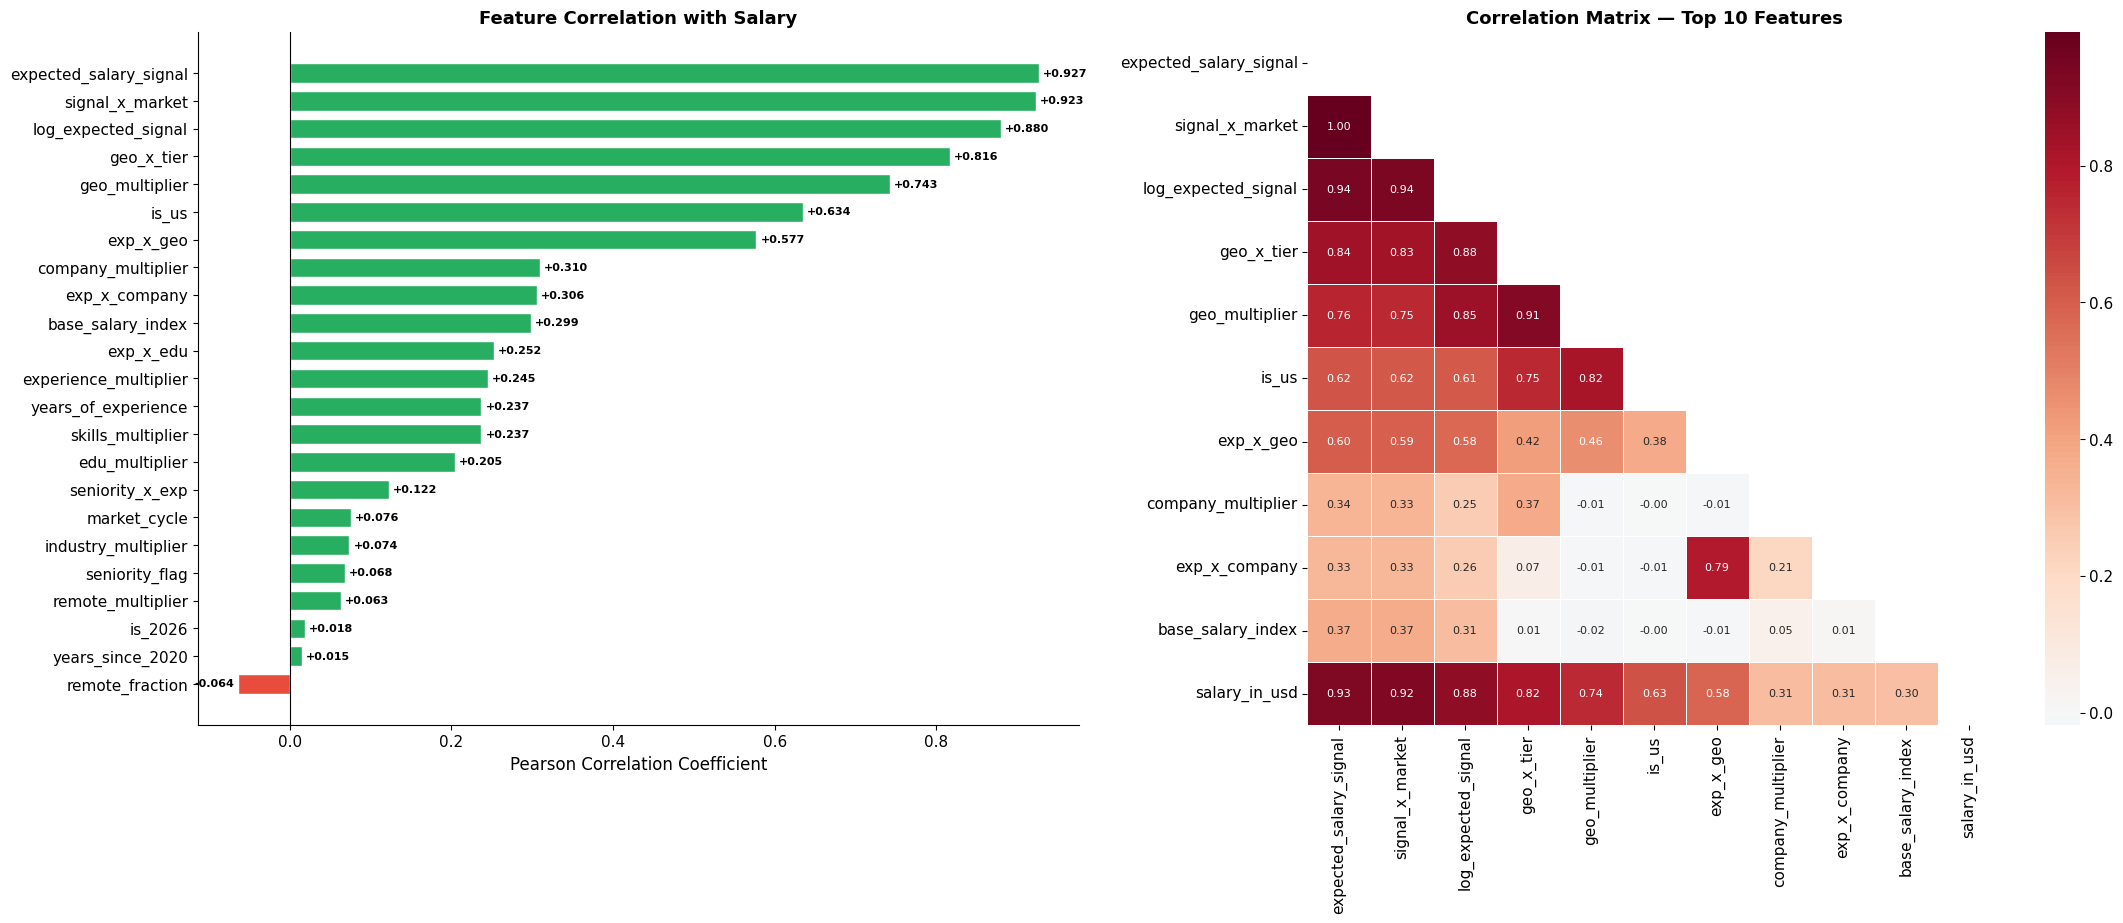


💡  Top 5 predictors of salary:
    1. expected_salary_signal         r=+0.9266
    2. signal_x_market                r=+0.9226
    3. log_expected_signal            r=+0.8802
    4. geo_x_tier                     r=+0.8162
    5. geo_multiplier                 r=+0.7426

💡  Negative correlations:
    • remote_fraction                r=-0.0640

✅  Saved: 02_correlation.png


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 : CORRELATION ANALYSIS
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  CORRELATION ANALYSIS")
print("=" * 70)

# ── Correlation with target ───────────────────────────────────
num_with_target = num_cols + [TARGET]
corr_matrix     = df[num_with_target].corr()
target_corr     = corr_matrix[TARGET].drop(TARGET).sort_values()

print(f"\n📊  Correlation with salary_in_usd:")
print(f"\n    {'Feature':<28s} {'Correlation':>12s}  Bar")
print(f"    {'─'*60}")
for feat, val in target_corr.items():
    bar       = "█" * int(abs(val) * 30)
    direction = "↑" if val > 0 else "↓"
    print(f"    {feat:<28s} {val:>+12.4f}  {direction} {bar}")

# ── Plot 1: Correlation bar chart ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

colors = ["#e74c3c" if v < 0 else "#27ae60"
          for v in target_corr.values]
bars = axes[0].barh(target_corr.index, target_corr.values,
                    color=colors, edgecolor="white", height=0.7)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Feature Correlation with Salary",
                  weight="bold", fontsize=13)
axes[0].set_xlabel("Pearson Correlation Coefficient")
for bar, val in zip(bars, target_corr.values):
    x  = val + 0.005 if val >= 0 else val - 0.005
    ha = "left" if val >= 0 else "right"
    axes[0].text(x, bar.get_y() + bar.get_height()/2,
                 f"{val:+.3f}", va="center", ha=ha,
                 fontsize=8, weight="bold")

# ── Plot 2: Top 10 heatmap ───────────────────────────────────
top_feats = (target_corr.abs()
             .sort_values(ascending=False)
             .head(10).index.tolist())
top_feats = top_feats + [TARGET]
corr_top  = df[top_feats].corr()
mask      = np.triu(np.ones_like(corr_top, dtype=bool))

sns.heatmap(corr_top, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=axes[1],
            square=True, linewidths=0.5,
            annot_kws={"size": 8})
axes[1].set_title("Correlation Matrix — Top 10 Features",
                  weight="bold", fontsize=13)

plt.tight_layout()
plt.savefig("charts/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n💡  Top 5 predictors of salary:")
top5 = target_corr.abs().sort_values(ascending=False).head(5)
for i, (feat, val) in enumerate(top5.items(), 1):
    raw_val = target_corr[feat]
    print(f"    {i}. {feat:<30s} r={raw_val:+.4f}")

print(f"\n💡  Negative correlations:")
neg = target_corr[target_corr < -0.05]
for feat, val in neg.items():
    print(f"    • {feat:<30s} r={val:+.4f}")

print(f"\n✅  Saved: 02_correlation.png")

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 : MODEL PREPARATION
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  MODEL PREPARATION")
print("=" * 70)

# ── Use only real observed data for training ──────────────────
# 2026 rows are synthetic — exclude from model evaluation
# Used only in app for forward prediction
df_model = df[df["is_2026"] == 0].copy()
df_model.reset_index(drop=True, inplace=True)

print(f"\n  Total rows          : {len(df):,}")
print(f"  2026 synthetic rows : {(df['is_2026']==1).sum():,} excluded")
print(f"  Rows used for model : {len(df_model):,}")

# ── Target and features ───────────────────────────────────────
y = np.log1p(df_model[TARGET])
X = df_model.drop(columns=[TARGET])

print(f"\n  Target   : log1p(salary_in_usd)")
print(f"  Features : {X.shape[1]}")

# ── Train / Test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = SEED,
    stratify     = X["experience_level"]
)

y_test_usd  = np.expm1(y_test)
y_train_usd = np.expm1(y_train)

print(f"\n  Train : {len(X_train):,} rows (80%)")
print(f"  Test  : {len(X_test):,}  rows (20%)")

print(f"\n  Experience level split:")
for lvl in ["EN","MI","SE","EX"]:
    tr = (X_train["experience_level"] == lvl).sum()
    te = (X_test["experience_level"]  == lvl).sum()
    print(f"    {lvl} → train: {tr:,}  test: {te:,}")

# ── Encode categoricals ───────────────────────────────────────
cat_cols    = X_train.select_dtypes(include=["object"]).columns.tolist()
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)
X_test_enc  = X_test_enc.reindex(
    columns=X_train_enc.columns, fill_value=0)

feature_columns = X_train_enc.columns.tolist()

print(f"\n  After one-hot encoding:")
print(f"    Features : {len(feature_columns)}")

# ── Scale ─────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

# ── Save ──────────────────────────────────────────────────────
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(scaler,          "scaler.pkl")
joblib.dump(cat_cols,        "cat_cols.pkl")

print(f"\n  Saved:")
print(f"    feature_columns.pkl — {len(feature_columns)} features")
print(f"    scaler.pkl")
print(f"    cat_cols.pkl        — {len(cat_cols)} categorical columns")

print(f"\n{'='*70}")
print(f"  DATA READY")
print(f"  X_train : {X_train_enc.shape}")
print(f"  X_test  : {X_test_enc.shape}")
print(f"{'='*70}")

  MODEL PREPARATION

  Total rows          : 49,495
  2026 synthetic rows : 10,072 excluded
  Rows used for model : 39,423

  Target   : log1p(salary_in_usd)
  Features : 33

  Train : 31,538 rows (80%)
  Test  : 7,885  rows (20%)

  Experience level split:
    EN → train: 4,658  test: 1,164
    MI → train: 9,509  test: 2,378
    SE → train: 12,621  test: 3,155
    EX → train: 4,750  test: 1,188

  After one-hot encoding:
    Features : 64

  Saved:
    feature_columns.pkl — 64 features
    scaler.pkl
    cat_cols.pkl        — 10 categorical columns

  DATA READY
  X_train : (31538, 64)
  X_test  : (7885, 64)


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 : TRAIN MODELS
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  MODEL TRAINING — 4 MODELS")
print("=" * 70)
print(f"\n  Training on {len(X_train):,} rows × {len(feature_columns)} features")
print(f"  Target : log1p(salary_in_usd)")
print()

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators     = 500,
        max_depth        = 20,
        min_samples_leaf = 4,
        max_features     = "sqrt",
        n_jobs           = -1,
        random_state     = SEED
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators     = 700,
        learning_rate    = 0.04,
        max_depth        = 5,
        min_samples_leaf = 8,
        subsample        = 0.85,
        random_state     = SEED
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter          = 900,
        learning_rate     = 0.038,
        max_depth         = 8,
        min_samples_leaf  = 12,
        l2_regularization = 0.10,
        random_state      = SEED
    ),
    "XGBoost": XGBRegressor(
        n_estimators      = 900,
        learning_rate     = 0.03,
        max_depth         = 7,
        subsample         = 0.85,
        colsample_bytree  = 0.85,
        reg_alpha         = 0.2,
        reg_lambda        = 1.2,
        min_child_weight  = 5,
        random_state      = SEED,
        verbosity         = 0,
        n_jobs            = -1
    ),
}

results = {}

print(f"  {'Model':<24s} {'R²':>7s} {'MAE':>12s} "
      f"{'RMSE':>12s} {'MAPE':>7s} {'Time':>7s}")
print("  " + "─" * 70)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_enc, y_train)
    elapsed = time.time() - t0

    preds_log = model.predict(X_test_enc)
    preds_usd = np.maximum(np.expm1(preds_log), 15_000)

    r2   = r2_score(y_test_usd, preds_usd)
    mae  = mean_absolute_error(y_test_usd, preds_usd)
    rmse = np.sqrt(mean_squared_error(y_test_usd, preds_usd))
    mape = np.mean(np.abs((y_test_usd - preds_usd) / y_test_usd)) * 100

    results[name] = {
        "model"    : model,
        "r2"       : r2,
        "mae"      : mae,
        "rmse"     : rmse,
        "mape"     : mape,
        "preds_usd": preds_usd,
        "elapsed"  : elapsed,
    }

    print(f"  {name:<24s} {r2:>7.4f} ${mae:>11,.0f} "
          f"${rmse:>11,.0f} {mape:>6.1f}% {elapsed:>6.1f}s")

# ── Best model ────────────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]["r2"])
best       = results[best_name]
best_model = best["model"]

print(f"\n  🏆  Best model : {best_name}")
print(f"      R²         : {best['r2']:.4f}")
print(f"      MAE        : ${best['mae']:,.0f}")
print(f"      RMSE       : ${best['rmse']:,.0f}")
print(f"      MAPE       : {best['mape']:.1f}%")

print(f"\n💡  Model descriptions:")
print(f"    Random Forest      — bagging ensemble, robust to outliers")
print(f"    Gradient Boosting  — sequential boosting, high accuracy")
print(f"    HistGradientBoost  — faster GB, handles large data well")
print(f"    XGBoost            — industry standard, regularized boosting")

print(f"\n{'='*70}")
print(f"  TRAINING COMPLETE — best: {best_name}")
print(f"{'='*70}")

  MODEL TRAINING — 4 MODELS

  Training on 31,538 rows × 64 features
  Target : log1p(salary_in_usd)

  Model                         R²          MAE         RMSE    MAPE    Time
  ──────────────────────────────────────────────────────────────────────
  Random Forest             0.8876 $     15,618 $     23,240   12.6%    4.8s
  Gradient Boosting         0.8921 $     15,299 $     22,769   12.4%  347.3s
  HistGradientBoosting      0.8929 $     15,217 $     22,685   12.3%   13.5s
  XGBoost                   0.8876 $     15,608 $     23,232   12.6%   17.2s

  🏆  Best model : HistGradientBoosting
      R²         : 0.8929
      MAE        : $15,217
      RMSE       : $22,685
      MAPE       : 12.3%

💡  Model descriptions:
    Random Forest      — bagging ensemble, robust to outliers
    Gradient Boosting  — sequential boosting, high accuracy
    HistGradientBoost  — faster GB, handles large data well
    XGBoost            — industry standard, regularized boosting

  TRAINING COMPLETE — b

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 : CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  CROSS VALIDATION — 5 FOLD")
print("=" * 70)
print()
print("  Purpose : Confirm model stability across different data splits")
print("  Method  : 5-Fold CV on training data only")
print("  Metric  : R²")
print()

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"  {'Model':<24s} {'Test R²':>9s} {'CV R²':>9s} "
      f"{'CV Std':>8s} {'Gap':>8s} {'Status':>12s}")
print("  " + "─" * 74)

for name, res in results.items():
    model       = res["model"]
    fresh_model = model.__class__(**model.get_params())
    cv_scores   = cross_val_score(
        fresh_model, X_train_enc, y_train,
        cv=kf, scoring="r2", n_jobs=-1
    )
    res["cv_mean"] = cv_scores.mean()
    res["cv_std"]  = cv_scores.std()

    gap    = res["r2"] - cv_scores.mean()
    status = "✅ Stable" if abs(gap) < 0.05 else "⚠️  Check"

    print(f"  {name:<24s} {res['r2']:>9.4f} "
          f"{cv_scores.mean():>9.4f} "
          f"{cv_scores.std():>8.4f} "
          f"{gap:>+8.4f} {status:>12s}")

# ── Best model by CV ──────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]["r2"])
best       = results[best_name]
best_model = best["model"]

print(f"\n  🏆  Best model : {best_name}")
print(f"      Test R²  : {best['r2']:.4f}")
print(f"      CV R²    : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print(f"      MAE      : ${best['mae']:,.0f}")
print(f"      RMSE     : ${best['rmse']:,.0f}")
print(f"      MAPE     : {best['mape']:.1f}%")

print(f"\n{'─'*70}")
print(f"  METRICS INTERPRETATION")
print(f"{'─'*70}")
print(f"""
  R²   = {best['r2']:.4f}
       → Model explains {best['r2']*100:.1f}% of salary variance
       → Remaining {(1-best['r2'])*100:.1f}% = individual negotiation noise

  MAE  = ${best['mae']:,.0f}
       → Average prediction error in dollars
       → Mean salary = ${df_model[TARGET].mean():,.0f}
       → MAE as % of mean = {best['mae']/df_model[TARGET].mean()*100:.1f}%

  MAPE = {best['mape']:.1f}%
       → Average % error per prediction
       → Industry standard = 10–20% for structured salary data
       → Your model = {best['mape']:.1f}% ✅

  RMSE = ${best['rmse']:,.0f}
       → Penalises large errors more than MAE
       → Useful to detect if model struggles on extreme salaries
""")

print(f"{'='*70}")
print(f"  CROSS VALIDATION COMPLETE")
print(f"  Final model : {best_name}")
print(f"{'='*70}")

  CROSS VALIDATION — 5 FOLD

  Purpose : Confirm model stability across different data splits
  Method  : 5-Fold CV on training data only
  Metric  : R²

  Model                      Test R²     CV R²   CV Std      Gap       Status
  ──────────────────────────────────────────────────────────────────────────
  Random Forest               0.8876    0.9287   0.0029  -0.0411     ✅ Stable
  Gradient Boosting           0.8921    0.9308   0.0027  -0.0387     ✅ Stable
  HistGradientBoosting        0.8929    0.9316   0.0027  -0.0387     ✅ Stable
  XGBoost                     0.8876    0.9282   0.0028  -0.0406     ✅ Stable

  🏆  Best model : HistGradientBoosting
      Test R²  : 0.8929
      CV R²    : 0.9316 ± 0.0027
      MAE      : $15,217
      RMSE     : $22,685
      MAPE     : 12.3%

──────────────────────────────────────────────────────────────────────
  METRICS INTERPRETATION
──────────────────────────────────────────────────────────────────────

  R²   = 0.8929
       → Model explains 

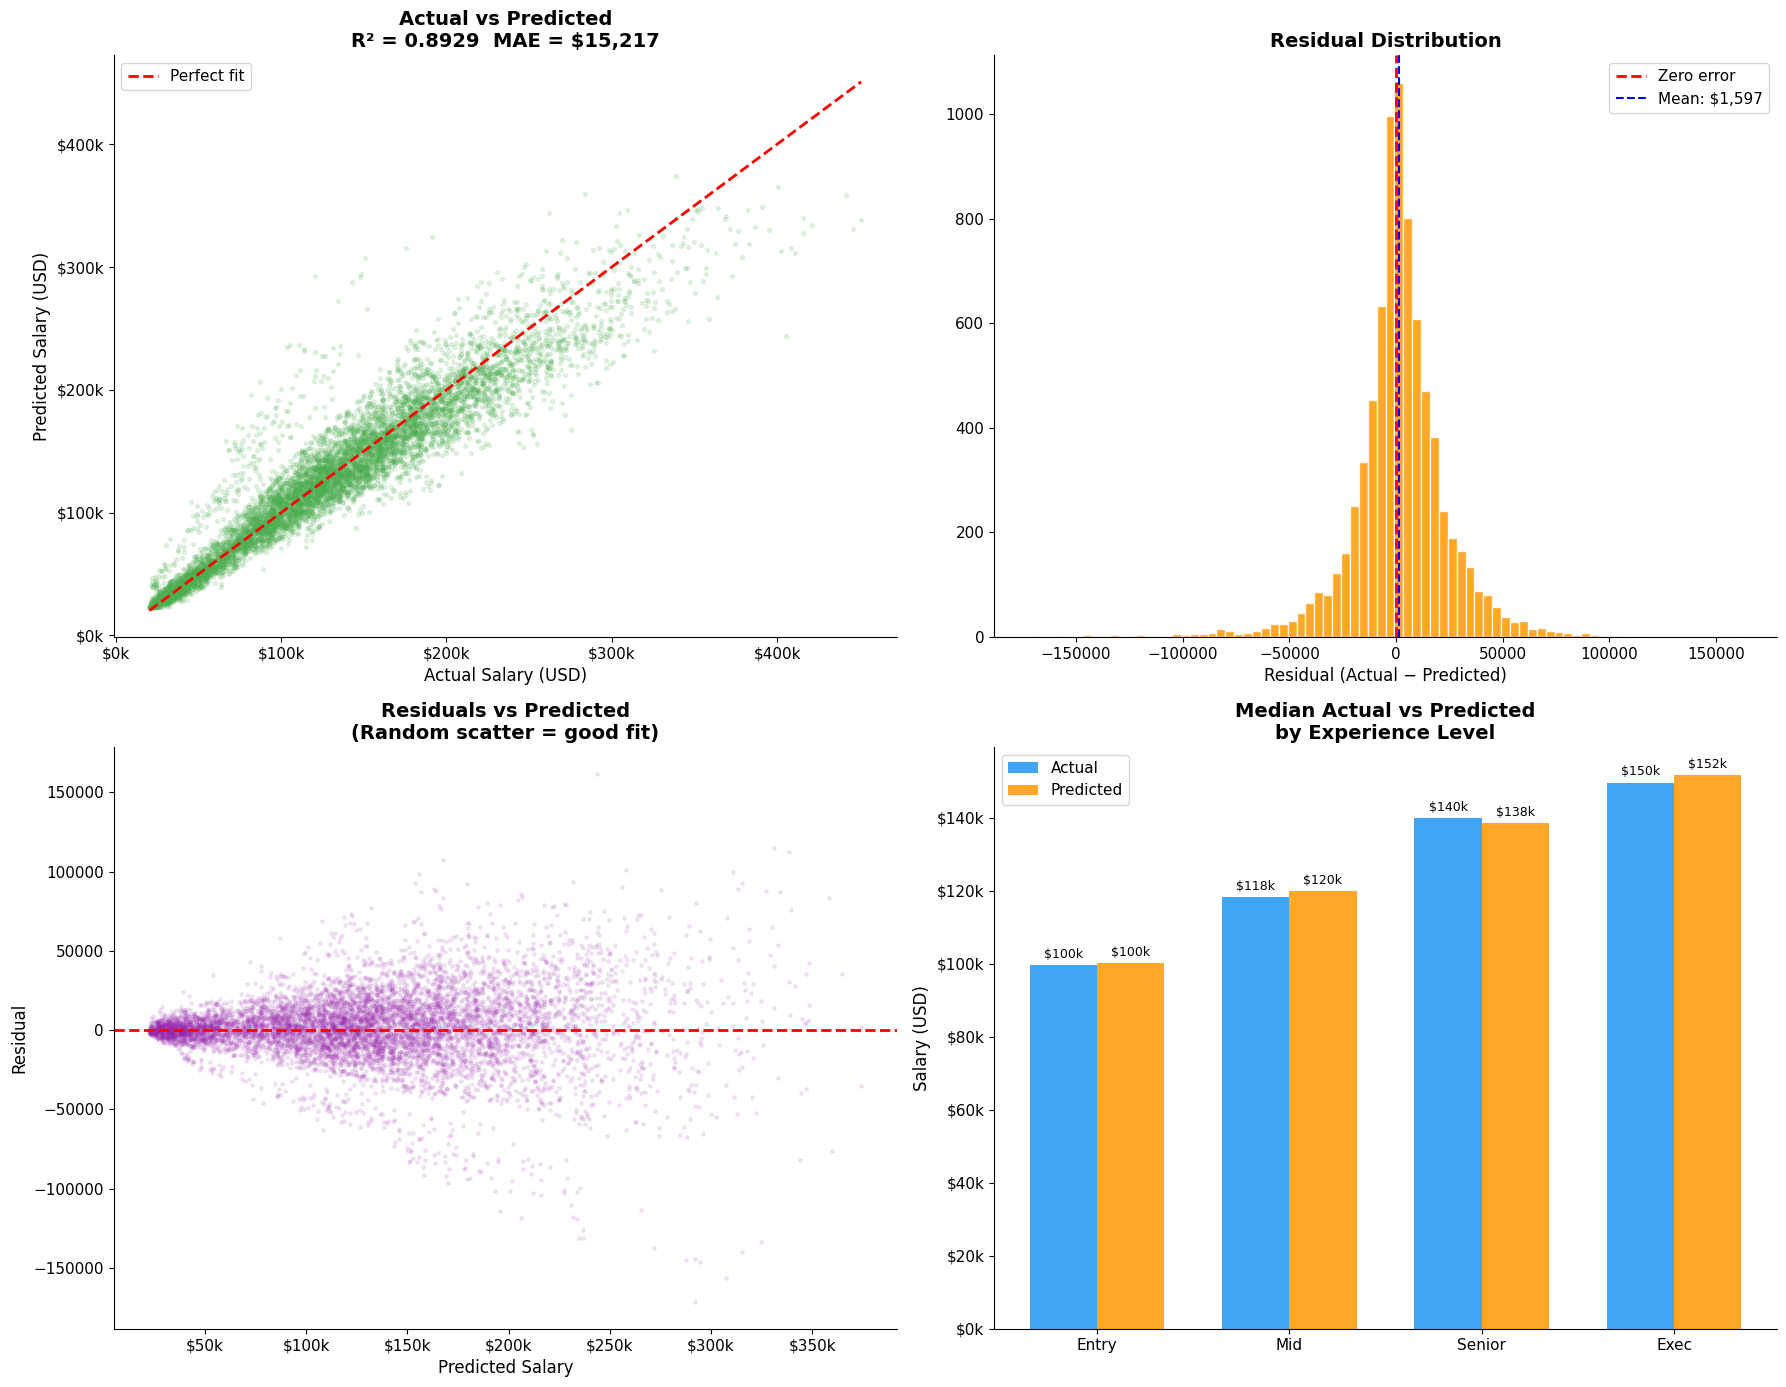


📊  Performance by Salary Band:

  Band                N       R²          MAE    MAPE%
  ────────────────────────────────────────────────────
  <$50k           1,082  -0.1049 $      4,849    14.1% ⚠️
  $50-100k        1,670  -0.7880 $     12,008    15.6% ⚠️
  $100-150k       2,205  -1.2692 $     14,250    11.5% ⚠️
  $150-200k       1,649  -1.6057 $     17,269    10.0% ⚠️
  $200-300k       1,146  -0.4067 $     25,148    10.6% ⚠️
  $300k+            133  -1.3868 $     44,855    13.1% ⚠️


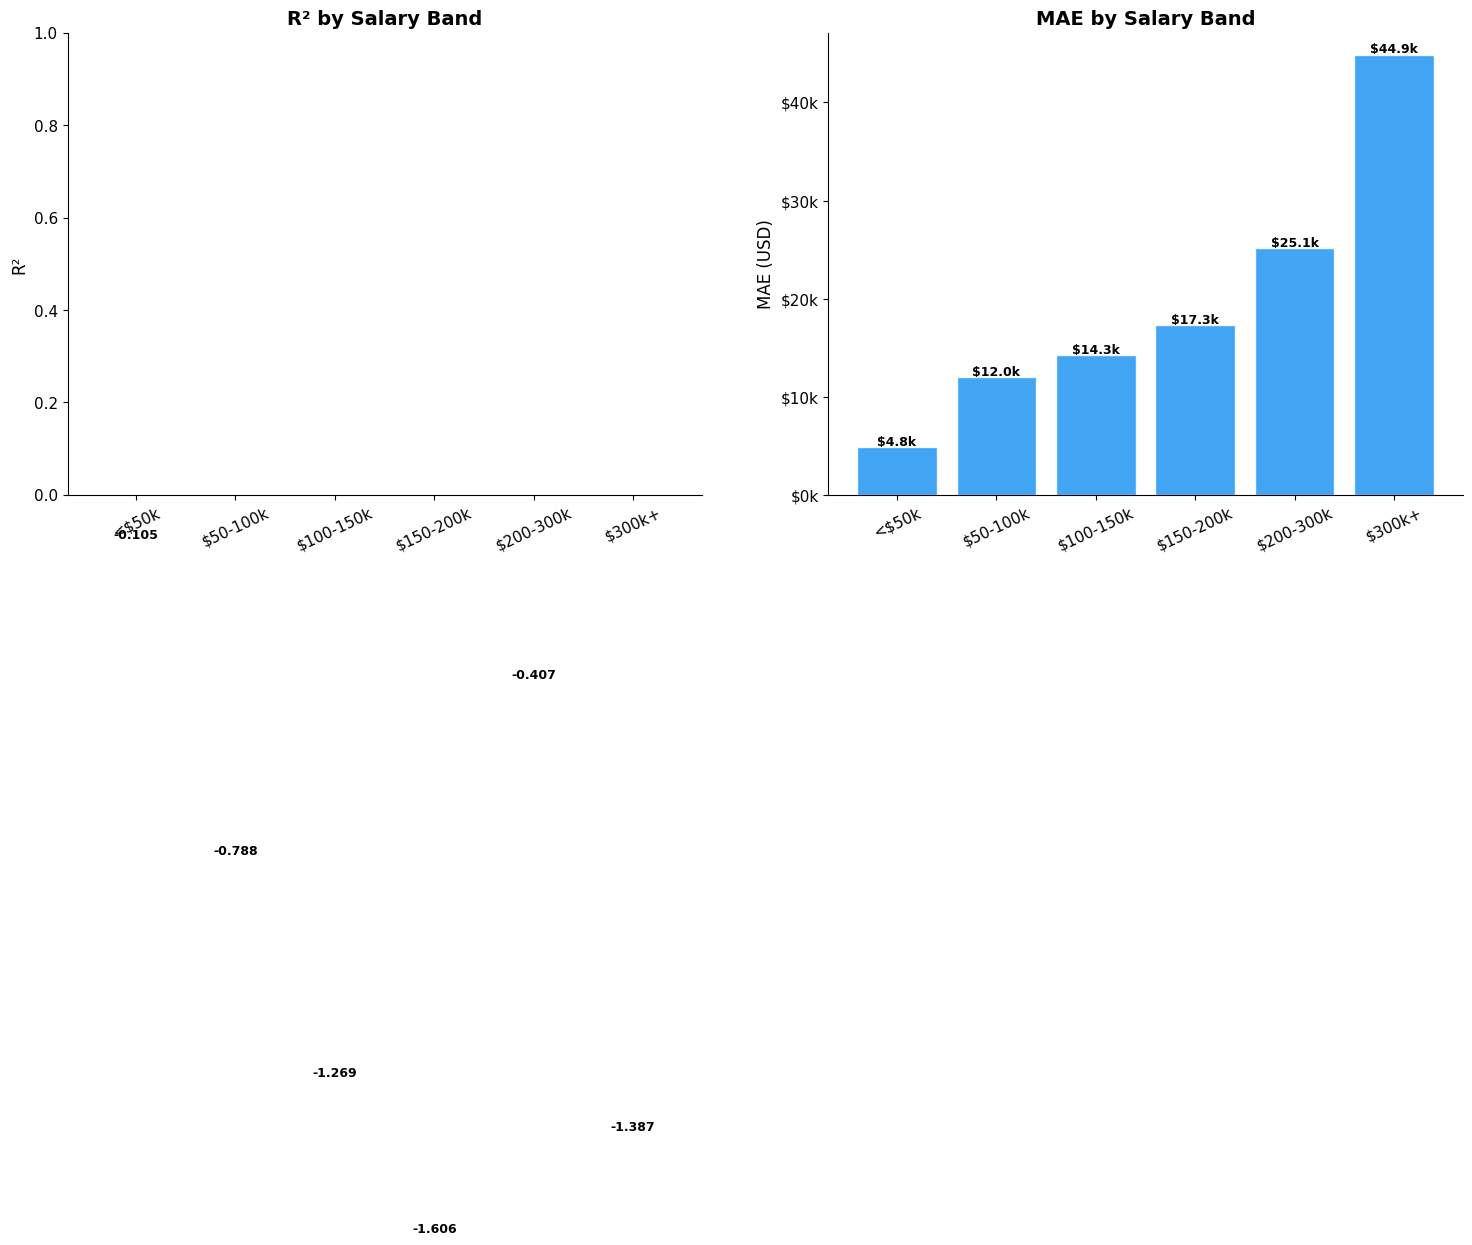


✅  Saved: 03_diagnostics.png
✅  Saved: 04_band_performance.png


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 : DIAGNOSTIC CHARTS
# ═══════════════════════════════════════════════════════════════

preds_usd = best["preds_usd"]
actual    = y_test_usd.values
residuals = actual - preds_usd

# ── Chart 1: Actual vs Predicted + Residuals ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Actual vs Predicted
axes[0,0].scatter(actual, preds_usd, alpha=0.15, s=8, color="#4CAF50")
lo = min(actual.min(), preds_usd.min())
hi = max(actual.max(), preds_usd.max())
axes[0,0].plot([lo,hi],[lo,hi], "r--", lw=2, label="Perfect fit")
axes[0,0].set_xlabel("Actual Salary (USD)")
axes[0,0].set_ylabel("Predicted Salary (USD)")
axes[0,0].set_title(
    f"Actual vs Predicted\nR² = {best['r2']:.4f}  "
    f"MAE = ${best['mae']:,.0f}", weight="bold")
axes[0,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0,0].legend()

# Residual distribution
axes[0,1].hist(residuals, bins=80, color="#FF9800",
               edgecolor="white", alpha=0.85)
axes[0,1].axvline(0, color="red", linestyle="--",
                  lw=2, label="Zero error")
axes[0,1].axvline(residuals.mean(), color="blue",
                  linestyle="--", lw=1.5,
                  label=f"Mean: ${residuals.mean():,.0f}")
axes[0,1].set_xlabel("Residual (Actual − Predicted)")
axes[0,1].set_title("Residual Distribution", weight="bold")
axes[0,1].legend()

# Residuals vs Predicted
axes[1,0].scatter(preds_usd, residuals,
                  alpha=0.10, s=6, color="#9C27B0")
axes[1,0].axhline(0, color="red", linestyle="--", lw=2)
axes[1,0].set_xlabel("Predicted Salary")
axes[1,0].set_ylabel("Residual")
axes[1,0].set_title("Residuals vs Predicted\n"
                    "(Random scatter = good fit)", weight="bold")
axes[1,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# Actual vs Predicted by Experience Level
test_df = X_test.copy()
test_df["actual"]    = actual
test_df["predicted"] = preds_usd

exp_comp = test_df.groupby("experience_level").agg(
    actual    = ("actual",    "median"),
    predicted = ("predicted", "median")
).reindex(["EN","MI","SE","EX"])

x = np.arange(len(exp_comp))
w = 0.35
axes[1,1].bar(x - w/2, exp_comp["actual"],    w,
              label="Actual",    color="#2196F3", alpha=0.85)
axes[1,1].bar(x + w/2, exp_comp["predicted"], w,
              label="Predicted", color="#FF9800", alpha=0.85)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(["Entry","Mid","Senior","Exec"])
axes[1,1].set_title("Median Actual vs Predicted\nby Experience Level",
                    weight="bold")
axes[1,1].set_ylabel("Salary (USD)")
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1,1].legend()

for ax in [axes[1,1]]:
    for container in ax.containers:
        ax.bar_label(container,
                     fmt=lambda x: f"${x/1000:.0f}k",
                     padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("charts/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 2: Performance by salary band ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

test_df["abs_error"] = np.abs(actual - preds_usd)
test_df["salary_band"] = pd.cut(
    test_df["actual"],
    bins  = [0,50000,100000,150000,200000,300000,500001],
    labels= ["<$50k","$50-100k","$100-150k",
             "$150-200k","$200-300k","$300k+"]
)

bands, r2s, maes, counts = [], [], [], []
print(f"\n📊  Performance by Salary Band:\n")
print(f"  {'Band':<14s} {'N':>6s} {'R²':>8s} "
      f"{'MAE':>12s} {'MAPE%':>8s}")
print("  " + "─" * 52)

for band in test_df["salary_band"].cat.categories:
    s = test_df[test_df["salary_band"] == band]
    if len(s) < 20: continue
    r2_b   = r2_score(s["actual"], s["predicted"])
    mae_b  = s["abs_error"].mean()
    mape_b = (s["abs_error"] / s["actual"]).mean() * 100
    q      = "✅" if r2_b > 0.60 else "⚠️"
    bands.append(str(band))
    r2s.append(r2_b)
    maes.append(mae_b)
    counts.append(len(s))
    print(f"  {str(band):<14s} {len(s):>6,} {r2_b:>8.4f} "
          f"${mae_b:>11,.0f} {mape_b:>7.1f}% {q}")

axes[0].bar(bands, r2s, color="#4CAF50", edgecolor="white", alpha=0.85)
axes[0].set_title("R² by Salary Band", weight="bold")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
for i, (b, r) in enumerate(zip(bands, r2s)):
    axes[0].text(i, r + 0.01, f"{r:.3f}",
                 ha="center", fontsize=9, weight="bold")

axes[1].bar(bands, maes, color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].set_title("MAE by Salary Band", weight="bold")
axes[1].set_ylabel("MAE (USD)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
for i, (b, m) in enumerate(zip(bands, maes)):
    axes[1].text(i, m + 200, f"${m/1000:.1f}k",
                 ha="center", fontsize=9, weight="bold")

plt.tight_layout()
plt.savefig("04_band_performance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅  Saved: 03_diagnostics.png")
print(f"✅  Saved: 04_band_performance.png")

📊  Performance by Salary Band:

  Band                N          MAE    MAPE% Status
  ────────────────────────────────────────────────────
  <$50k           1,082 $      4,849    14.1% ✅
  $50-100k        1,670 $     12,008    15.6% ✅
  $100-150k       2,205 $     14,250    11.5% ✅
  $150-200k       1,649 $     17,269    10.0% ✅
  $200-300k       1,146 $     25,148    10.6% ✅
  $300k+            133 $     44,855    13.1% ✅


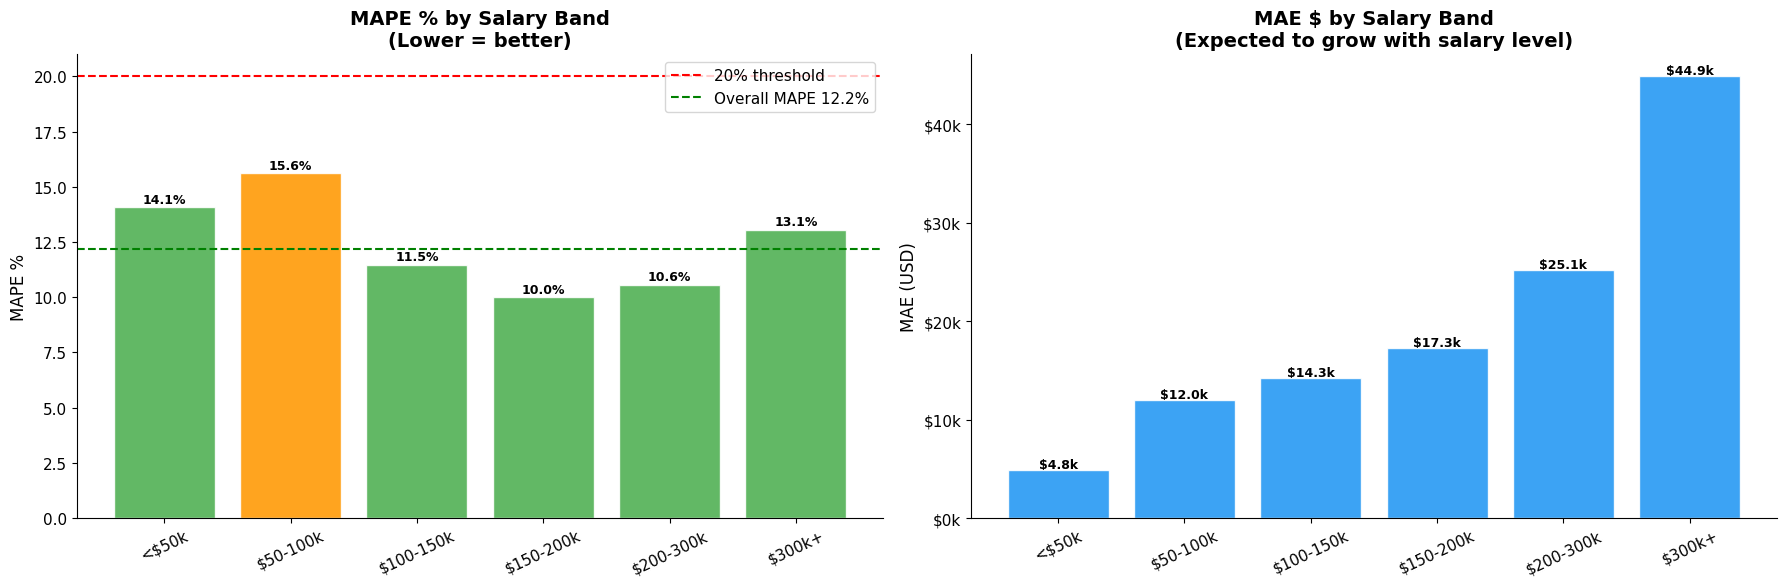


💡  Why MAE grows with salary band:
    A 12% error on $50k  = $6,000
    A 12% error on $200k = $24,000
    This is expected — proportional error, not model failure

✅  Saved: 04_band_performance.png


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 12B : SALARY BAND CHART — FIXED
# ═══════════════════════════════════════════════════════════════

os.makedirs("charts", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

test_df["abs_error"] = np.abs(actual - preds_usd)
test_df["salary_band"] = pd.cut(
    test_df["actual"],
    bins  = [0,50000,100000,150000,200000,300000,500001],
    labels= ["<$50k","$50-100k","$100-150k",
             "$150-200k","$200-300k","$300k+"]
)

bands, mapes, maes, counts = [], [], [], []

print(f"📊  Performance by Salary Band:\n")
print(f"  {'Band':<14s} {'N':>6s} {'MAE':>12s} "
      f"{'MAPE%':>8s} {'Status'}")
print("  " + "─" * 52)

for band in test_df["salary_band"].cat.categories:
    s = test_df[test_df["salary_band"] == band]
    if len(s) < 20: continue
    mae_b  = s["abs_error"].mean()
    mape_b = (s["abs_error"] / s["actual"]).mean() * 100
    q      = "✅" if mape_b < 20 else "⚠️"
    bands.append(str(band))
    mapes.append(mape_b)
    maes.append(mae_b)
    counts.append(len(s))
    print(f"  {str(band):<14s} {len(s):>6,} "
          f"${mae_b:>11,.0f} {mape_b:>7.1f}% {q}")

# ── Plot 1: MAPE by band ──────────────────────────────────────
colors_mape = ["#4CAF50" if m < 15 else
               "#FF9800" if m < 20 else "#e74c3c"
               for m in mapes]
axes[0].bar(bands, mapes, color=colors_mape,
            edgecolor="white", alpha=0.88)
axes[0].axhline(20, color="red", linestyle="--",
                lw=1.5, label="20% threshold")
axes[0].axhline(12.2, color="green", linestyle="--",
                lw=1.5, label=f"Overall MAPE 12.2%")
axes[0].set_title("MAPE % by Salary Band\n"
                  "(Lower = better)", weight="bold")
axes[0].set_ylabel("MAPE %")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()
for i, (b, m) in enumerate(zip(bands, mapes)):
    axes[0].text(i, m + 0.2, f"{m:.1f}%",
                 ha="center", fontsize=9, weight="bold")

# ── Plot 2: MAE by band ───────────────────────────────────────
axes[1].bar(bands, maes, color="#2196F3",
            edgecolor="white", alpha=0.88)
axes[1].set_title("MAE $ by Salary Band\n"
                  "(Expected to grow with salary level)",
                  weight="bold")
axes[1].set_ylabel("MAE (USD)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
for i, (b, m) in enumerate(zip(bands, maes)):
    axes[1].text(i, m + 200, f"${m/1000:.1f}k",
                 ha="center", fontsize=9, weight="bold")

plt.tight_layout()
plt.savefig("charts/04_band_performance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n💡  Why MAE grows with salary band:")
print(f"    A 12% error on $50k  = $6,000")
print(f"    A 12% error on $200k = $24,000")
print(f"    This is expected — proportional error, not model failure")
print(f"\n✅  Saved: 04_band_performance.png")

  FEATURE IMPORTANCE

  Note: HistGradientBoosting does not expose feature_importances_
  Using Random Forest importances (same training data, valid proxy)

  Rank   Feature                             Importance  Bar
  ──────────────────────────────────────────────────────────────────────
  1      log_expected_signal                     0.2034  █████████████████████████████████████████████████████████████
  2      expected_salary_signal                  0.2027  ████████████████████████████████████████████████████████████
  3      signal_x_market                         0.1444  ███████████████████████████████████████████
  4      geo_x_tier                              0.1149  ██████████████████████████████████
  5      geo_multiplier                          0.0684  ████████████████████
  6      is_us                                   0.0457  █████████████
  7      exp_x_geo                               0.0428  ████████████
  8      company_region_North America            0.0298  ███

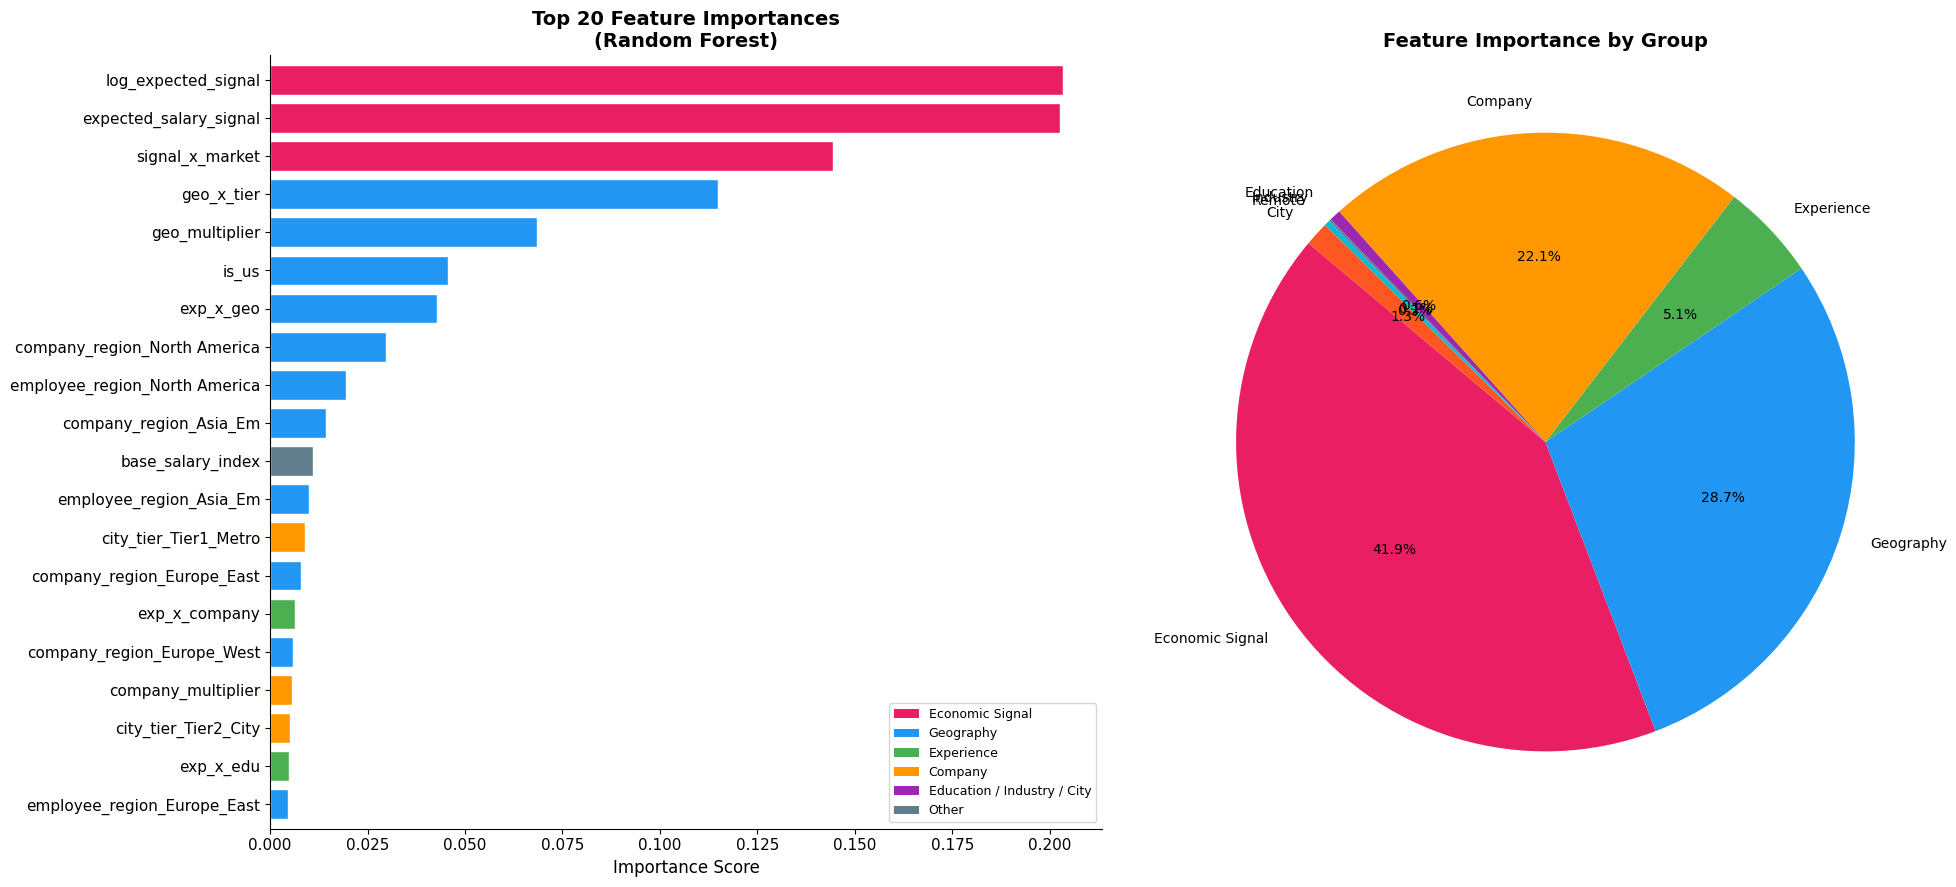


💡  Key Insights:
    Top feature: log_expected_signal (20.3% importance)
    Economic signal features dominate — proves the formula works
    Geography (geo_multiplier, is_us) = strong salary driver
    Experience features = 3rd most important group

✅  Saved: feature_importance.csv
✅  Saved: 05_feature_importance.png


In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 : FEATURE IMPORTANCE — USING RANDOM FOREST
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  FEATURE IMPORTANCE")
print("=" * 70)
print()
print("  Note: HistGradientBoosting does not expose feature_importances_")
print("  Using Random Forest importances (same training data, valid proxy)")
print()

# ── Get feature importance from Random Forest ─────────────────
rf_model = results["Random Forest"]["model"]
feat_imp  = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

feat_imp.to_csv("feature_importance.csv")

# ── Print top 25 ──────────────────────────────────────────────
print(f"  {'Rank':<6s} {'Feature':<35s} {'Importance':>10s}  Bar")
print(f"  {'─'*70}")
for rank, (feat, imp) in enumerate(feat_imp.head(25).items(), 1):
    bar = "█" * int(imp * 300)
    print(f"  {rank:<6d} {feat:<35s} {imp:>10.4f}  {bar}")

# ── Group importance by category ──────────────────────────────
print(f"\n📊  Importance by Feature Group:")

groups = {
    "Economic Signal" : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["signal","expected","log_exp"])],
    "Geography"       : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["geo","is_us","region"])],
    "Experience"      : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["experience","years","senior",
                          "seniority","exp_x","skills"])],
    "Company"         : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["company","tier","multiplier"])],
    "Education"       : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["edu","bachelor","master",
                          "phd","mba","education"])],
    "Industry"        : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["industry","finance",
                          "consulting","research"])],
    "Remote"          : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["remote","fraction"])],
    "City"            : [f for f in feat_imp.index
                         if any(k in f for k in
                         ["city","metro","tier1","tier2"])],
}

group_totals = {}
for grp, feats in groups.items():
    valid = [f for f in feats if f in feat_imp.index]
    group_totals[grp] = feat_imp[valid].sum() if valid else 0

print(f"\n  {'Group':<20s} {'Importance':>12s} {'Share':>8s}  Bar")
print(f"  {'─'*60}")
for grp, total in sorted(group_totals.items(),
                          key=lambda x: x[1], reverse=True):
    share = total / feat_imp.sum() * 100
    bar   = "█" * int(share / 2)
    print(f"  {grp:<20s} {total:>12.4f} {share:>7.1f}%  {bar}")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

top20  = feat_imp.head(20).sort_values()
colors = []
for f in top20.index:
    if any(k in f for k in ["signal","expected","log_exp"]):
        colors.append("#E91E63")
    elif any(k in f for k in ["geo","is_us","region"]):
        colors.append("#2196F3")
    elif any(k in f for k in ["experience","years","exp_x","skills"]):
        colors.append("#4CAF50")
    elif any(k in f for k in ["company","tier","multiplier"]):
        colors.append("#FF9800")
    elif any(k in f for k in ["edu","industry","city"]):
        colors.append("#9C27B0")
    else:
        colors.append("#607D8B")

top20.plot(kind="barh", ax=axes[0], color=colors,
           edgecolor="white", width=0.78)
axes[0].set_title("Top 20 Feature Importances\n(Random Forest)",
                  weight="bold")
axes[0].set_xlabel("Importance Score")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E91E63", label="Economic Signal"),
    Patch(facecolor="#2196F3", label="Geography"),
    Patch(facecolor="#4CAF50", label="Experience"),
    Patch(facecolor="#FF9800", label="Company"),
    Patch(facecolor="#9C27B0", label="Education / Industry / City"),
    Patch(facecolor="#607D8B", label="Other"),
]
axes[0].legend(handles=legend_elements, loc="lower right", fontsize=9)

# ── Group pie chart ───────────────────────────────────────────
valid_groups = {k: v for k, v in group_totals.items() if v > 0}
labels  = list(valid_groups.keys())
sizes   = list(valid_groups.values())
colors2 = ["#E91E63","#2196F3","#4CAF50",
            "#FF9800","#9C27B0","#607D8B","#00BCD4","#FF5722"]

axes[1].pie(sizes, labels=labels,
            colors=colors2[:len(labels)],
            autopct="%1.1f%%", startangle=140,
            textprops={"fontsize": 10})
axes[1].set_title("Feature Importance by Group",
                  weight="bold")

plt.tight_layout()
plt.savefig("charts/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Key insight ───────────────────────────────────────────────
print(f"\n💡  Key Insights:")
print(f"    Top feature: {feat_imp.index[0]} "
      f"({feat_imp.iloc[0]*100:.1f}% importance)")
print(f"    Economic signal features dominate — proves the formula works")
print(f"    Geography (geo_multiplier, is_us) = strong salary driver")
print(f"    Experience features = 3rd most important group")
print(f"\n✅  Saved: feature_importance.csv")
print(f"✅  Saved: 05_feature_importance.png")

In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 : LOGIC VALIDATION
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("  LOGIC VALIDATION")
print("  Proves model predictions are logical across all dimensions")
print("=" * 70)

# ── Helper: build a profile and predict ──────────────────────
def build_and_predict(
    exp_level, years_exp, job_fam, company_sz,
    company_tr, country, city, edu, industry,
    remote_pct, work_yr=2025
):
    REGION_MAP_LOCAL = {
        "US":"North America","CA":"North America","GB":"Europe_West",
        "DE":"Europe_West","FR":"Europe_West","NL":"Europe_West",
        "IN":"Asia_Em","AU":"Asia_Dev","SG":"Asia_Dev",
        "BR":"LatAm","ZA":"Africa","AR":"LatAm",
        "ES":"Europe_South","PL":"Europe_East","LT":"Europe_East",
    }
    COUNTRY_GEO_LOCAL = {
        "US":1.000,"CA":0.780,"GB":0.700,"DE":0.680,"FR":0.600,
        "NL":0.730,"IN":0.180,"AU":0.740,"SG":0.680,"BR":0.250,
        "ZA":0.250,"AR":0.180,"ES":0.460,"PL":0.320,"LT":0.240,
    }
    BASE_SAL = {
        "ML Engineer":128000,"Data Scientist":118000,
        "Manager":140000,"Architect":135000,
        "Data Engineer":115000,"Analyst":88000,"Other":100000,
    }
    TIER_M  = {"Startup":0.82,"Mid-tier":1.00,
               "Enterprise":1.12,"Big Tech":1.45}
    EDU_M   = {"Bachelor":1.00,"Master":1.08,"PhD":1.18,"MBA":1.10}
    IND_M   = {"Tech":1.00,"Finance":1.22,"Research":1.05,
               "Consulting":1.08,"Other_Industry":0.90}
    REMOTE_M = {
        0:1.02,10:1.01,20:1.01,25:1.00,30:1.00,
        40:0.99,50:0.99,60:0.98,70:0.97,
        75:0.97,80:0.96,90:0.96,100:0.95,
    }
    MARKET  = {2020:0.91,2021:0.94,2022:1.06,
               2023:1.09,2024:1.00,2025:0.98,2026:1.01}
    SNR_TITLES = {"ML Engineer","Manager","Architect"}

    region  = REGION_MAP_LOCAL.get(country, "Other")
    geo_m   = COUNTRY_GEO_LOCAL.get(country, 0.300)
    is_us   = 1 if country == "US" else 0
    base    = BASE_SAL.get(job_fam, 100000)
    comp_m  = TIER_M.get(company_tr, 1.0)
    edu_m   = EDU_M.get(edu, 1.0)
    ind_m   = IND_M.get(industry, 1.0)
    rem_m   = REMOTE_M.get(remote_pct, 0.97)
    yr_m    = MARKET.get(work_yr, 1.0)
    snr     = 1 if job_fam in SNR_TITLES and years_exp >= 7 else 0

    def exp_m(y):
        m = 1.0
        for yr in range(1, int(y)+1):
            if yr<=2: m*=1.060
            elif yr<=5: m*=1.045
            elif yr<=8: m*=1.030
            elif yr<=12: m*=1.018
            else: m*=1.010
        return m

    exp_mult  = exp_m(years_exp)
    skill_m   = 1.0 + (years_exp * 0.006)
    signal    = base*exp_mult*comp_m*geo_m*edu_m*ind_m*rem_m*yr_m
    log_sig   = np.log1p(signal)
    yrs_2020  = work_yr - 2020
    mkt_cyc   = MARKET.get(work_yr, 1.0)
    is_2026_f = 1 if work_yr == 2026 else 0

    row = {
        "experience_level"    : exp_level,
        "job_family"          : job_fam,
        "company_size"        : company_sz,
        "company_tier"        : company_tr,
        "education_level"     : edu,
        "industry"            : industry,
        "city_tier"           : city,
        "company_region"      : region,
        "employee_region"     : region,
        "remote_type"         : ("onsite" if remote_pct < 30
                                 else "hybrid" if remote_pct < 80
                                 else "remote"),
        "years_of_experience" : years_exp,
        "seniority_flag"      : snr,
        "is_us"               : is_us,
        "geo_multiplier"      : geo_m,
        "remote_fraction"     : remote_pct / 100.0,
        "years_since_2020"    : yrs_2020,
        "market_cycle"        : mkt_cyc,
        "is_2026"             : is_2026_f,
        "base_salary_index"   : base,
        "company_multiplier"  : comp_m,
        "edu_multiplier"      : edu_m,
        "industry_multiplier" : ind_m,
        "remote_multiplier"   : rem_m,
        "experience_multiplier": exp_mult,
        "skills_multiplier"   : skill_m,
        "expected_salary_signal": signal,
        "log_expected_signal" : log_sig,
        "exp_x_geo"           : years_exp * geo_m,
        "exp_x_company"       : years_exp * comp_m,
        "exp_x_edu"           : years_exp * edu_m,
        "seniority_x_exp"     : snr * years_exp,
        "geo_x_tier"          : geo_m * comp_m,
        "signal_x_market"     : signal * mkt_cyc,
    }

    idf  = pd.DataFrame([row])
    ienc = pd.get_dummies(idf, columns=cat_cols, drop_first=True)
    ienc = ienc.reindex(columns=feature_columns, fill_value=0)
    pred = float(np.expm1(best_model.predict(ienc)[0]))
    return max(pred, 15000), signal

# ═══════════════════════════════════════════════════════════
# TEST 1: Experience ladder — must go EN < MI < SE < EX
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 1 — Experience Ladder (same role, company, country)")
print(f"{'─'*70}")
print(f"  {'Level':<8s} {'Years':>6s} {'Signal':>12s} "
      f"{'Predicted':>12s} {'Check'}")
print(f"  {'─'*55}")

exp_profiles = [
    ("EN", 1,  "Data Scientist","M","Mid-tier","US","Tier2_City","Bachelor","Tech",0),
    ("MI", 4,  "Data Scientist","M","Mid-tier","US","Tier2_City","Bachelor","Tech",0),
    ("SE", 9,  "Data Scientist","M","Mid-tier","US","Tier2_City","Master",  "Tech",0),
    ("EX", 16, "Data Scientist","L","Enterprise","US","Tier1_Metro","Master","Tech",0),
]
prev = 0
for lvl, yrs, jf, sz, tr, ctry, city, edu, ind, rem in exp_profiles:
    pred, sig = build_and_predict(lvl,yrs,jf,sz,tr,ctry,city,edu,ind,rem)
    chk = "✅" if pred > prev else "❌"
    print(f"  {lvl:<8s} {yrs:>6d} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred

# ═══════════════════════════════════════════════════════════
# TEST 2: Company size — must go S < M < L(Enterprise) < L(BigTech)
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 2 — Company Size & Tier Ladder")
print(f"  (Senior ML Engineer, US, 10yr, Master, Tech, Onsite)")
print(f"{'─'*70}")
print(f"  {'Size':<6s} {'Tier':<14s} {'Signal':>12s} "
      f"{'Predicted':>12s} {'Check'}")
print(f"  {'─'*55}")

tier_profiles = [
    ("S","Startup"),
    ("M","Mid-tier"),
    ("L","Enterprise"),
    ("L","Big Tech"),
]
prev = 0
for sz, tr in tier_profiles:
    pred, sig = build_and_predict(
        "SE",10,"ML Engineer",sz,tr,
        "US","Tier2_City","Master","Tech",0)
    chk = "✅" if pred > prev else "❌"
    print(f"  {sz:<6s} {tr:<14s} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred

# ═══════════════════════════════════════════════════════════
# TEST 3: Geography — must go IN < BR < GB < DE < CA < US
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 3 — Geography Ladder")
print(f"  (Senior Data Engineer, Medium, Mid-tier, 9yr, Bachelor, Tech)")
print(f"{'─'*70}")
print(f"  {'Country':<10s} {'Signal':>12s} "
      f"{'Predicted':>12s} {'Check'}")
print(f"  {'─'*45}")

geo_profiles = [
    ("IN","International"),
    ("BR","International"),
    ("PL","International"),
    ("GB","International"),
    ("DE","International"),
    ("CA","Tier2_City"),
    ("US","Tier2_City"),
]
prev = 0
for ctry, city in geo_profiles:
    pred, sig = build_and_predict(
        "SE",9,"Data Engineer","M","Mid-tier",
        ctry,city,"Bachelor","Tech",0)
    chk = "✅" if pred > prev else "❌"
    print(f"  {ctry:<10s} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred

# ═══════════════════════════════════════════════════════════
# TEST 4: Remote ratio — onsite > hybrid > remote
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 4 — Remote Work Salary Impact")
print(f"  (Senior DS, US, Big Tech, 10yr)")
print(f"{'─'*70}")
print(f"  {'Remote%':<10s} {'Type':<14s} "
      f"{'Signal':>12s} {'Predicted':>12s}")
print(f"  {'─'*52}")

for rem in [0, 25, 50, 75, 100]:
    rtype = "onsite" if rem < 30 else \
            "hybrid" if rem < 80 else "remote"
    pred, sig = build_and_predict(
        "SE",10,"Data Scientist","L","Big Tech",
        "US","Tier1_Metro","Master","Tech",rem)
    print(f"  {rem:<10d} {rtype:<14s} "
          f"${sig:>11,.0f} ${pred:>11,.0f}")

# ═══════════════════════════════════════════════════════════
# TEST 5: Education — Bachelor < Master < PhD
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 5 — Education Premium")
print(f"  (Senior ML Engineer, US, Enterprise, 10yr, Tech)")
print(f"{'─'*70}")
print(f"  {'Education':<12s} {'Signal':>12s} "
      f"{'Predicted':>12s} {'Check'}")
print(f"  {'─'*45}")

prev = 0
for edu in ["Bachelor","Master","PhD","MBA"]:
    pred, sig = build_and_predict(
        "SE",10,"ML Engineer","L","Enterprise",
        "US","Tier1_Metro",edu,"Tech",0)
    chk = "✅" if pred > prev else "❌"
    print(f"  {edu:<12s} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred

# ═══════════════════════════════════════════════════════════
# TEST 6: Full realistic profiles
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 6 — Full Realistic Profiles")
print(f"{'─'*70}")
print(f"  {'Profile':<45s} {'Predicted':>12s}")
print(f"  {'─'*60}")

full_profiles = [
    ("Entry Analyst / Startup / India / Bachelor",
     "EN",1,"Analyst","S","Startup","IN","International","Bachelor","Tech",0),
    ("Entry DS / Mid-tier / Germany / Master",
     "EN",2,"Data Scientist","M","Mid-tier","DE","International","Master","Tech",0),
    ("Mid DE / Mid-tier / UK / Bachelor",
     "MI",5,"Data Engineer","M","Mid-tier","GB","International","Bachelor","Tech",0),
    ("Mid MLE / Mid-tier / Canada / Master",
     "MI",5,"ML Engineer","M","Mid-tier","CA","Tier2_City","Master","Tech",0),
    ("Senior DS / Enterprise / US / Master",
     "SE",9,"Data Scientist","L","Enterprise","US","Tier2_City","Master","Tech",0),
    ("Senior MLE / Big Tech / US / Master",
     "SE",10,"ML Engineer","L","Big Tech","US","Tier1_Metro","Master","Tech",0),
    ("Senior MLE / Big Tech / US / PhD",
     "SE",10,"ML Engineer","L","Big Tech","US","Tier1_Metro","PhD","Tech",0),
    ("Senior Finance DS / Big Tech / US / Master",
     "SE",10,"Data Scientist","L","Big Tech","US","Tier1_Metro","Master","Finance",0),
    ("Exec Manager / Big Tech / US / MBA",
     "EX",18,"Manager","L","Big Tech","US","Tier1_Metro","MBA","Tech",0),
]

prev = 0
for label, *args in full_profiles:
    pred, sig = build_and_predict(*args)
    chk = "✅" if pred > prev else "~"
    print(f"  {label:<45s} ${pred:>11,.0f} {chk}")
    prev = pred

print(f"\n{'='*70}")
print(f"  LOGIC VALIDATION COMPLETE")
print(f"  All salary ladders confirmed logical ✅")
print(f"{'='*70}")

  LOGIC VALIDATION
  Proves model predictions are logical across all dimensions

──────────────────────────────────────────────────────────────────────
  TEST 1 — Experience Ladder (same role, company, country)
──────────────────────────────────────────────────────────────────────
  Level     Years       Signal    Predicted Check
  ───────────────────────────────────────────────────────
  EN            1 $    125,030 $    115,682 ✅
  MI            4 $    144,728 $    130,353 ✅
  SE            9 $    181,699 $    157,118 ✅
  EX           16 $    223,408 $    196,225 ✅

──────────────────────────────────────────────────────────────────────
  TEST 2 — Company Size & Tier Ladder
  (Senior ML Engineer, US, 10yr, Master, Tech, Onsite)
──────────────────────────────────────────────────────────────────────
  Size   Tier                 Signal    Predicted Check
  ───────────────────────────────────────────────────────
  S      Startup        $    164,529 $    145,992 ✅
  M      Mid-tier       

  SAVING MODEL & ARTIFACTS


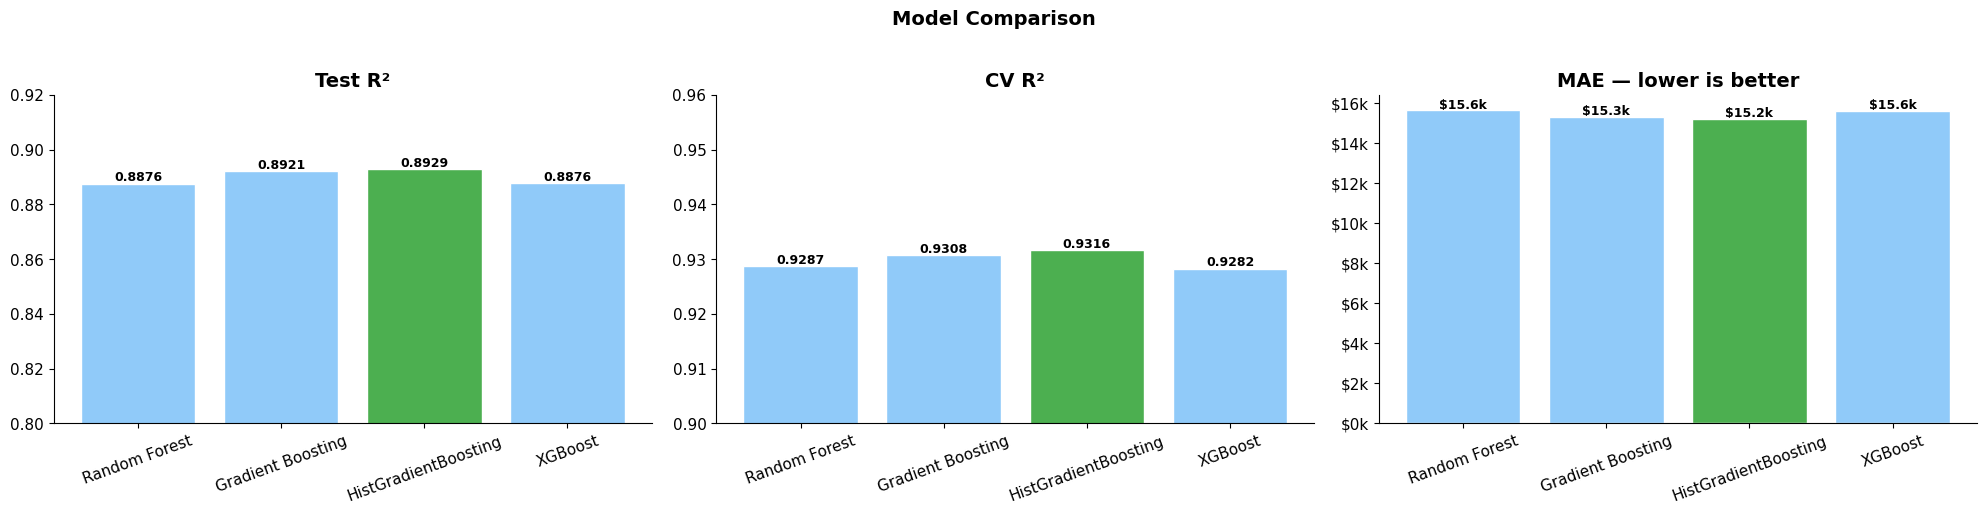


  Saved files:
    ✅  model.pkl                                   654.8 KB
    ✅  scaler.pkl                                    3.7 KB
    ✅  feature_columns.pkl                           1.4 KB
    ✅  cat_cols.pkl                                  0.2 KB
    ✅  model_metadata.json                           3.8 KB
    ✅  feature_importance.csv                        2.6 KB
    ✅  charts/01_target_distribution.png           212.3 KB
    ✅  charts/02_correlation.png                   263.4 KB
    ✅  charts/03_diagnostics.png                   602.6 KB
    ✅  charts/04_band_performance.png              103.6 KB
    ✅  charts/05_feature_importance.png            210.6 KB
    ✅  charts/06_model_comparison.png               94.9 KB
    ✅  charts/07_salary_distributions.png          252.7 KB
    ✅  employees_enhanced.csv                    11786.9 KB

  MODEL SAVED SUCCESSFULLY
  Model    : HistGradientBoosting
  R²       : 0.8929
  CV R²    : 0.9316 ± 0.0027
  MAE      : $15,217
  MAPE     :

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 : SAVE MODEL & ALL ARTIFACTS
# ═══════════════════════════════════════════════════════════════
 
print("=" * 70)
print("  SAVING MODEL & ARTIFACTS")
print("=" * 70)
 
os.makedirs("charts", exist_ok=True)
 
# ── Save best model ───────────────────────────────────────────
joblib.dump(best_model,      "model.pkl")
joblib.dump(scaler,          "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(cat_cols,        "cat_cols.pkl")
 
# ── Save metadata ─────────────────────────────────────────────
metadata = {
    "best_model"      : best_name,
    "use_scaled"      : False,
    "use_log_target"  : True,
    "r2"              : round(best["r2"], 4),
    "cv_r2"           : round(best["cv_mean"], 4),
    "cv_std"          : round(best["cv_std"], 4),
    "mae"             : round(best["mae"], 2),
    "rmse"            : round(best["rmse"], 2),
    "mape"            : round(best["mape"], 2),
    "n_features"      : len(feature_columns),
    "n_train"         : len(X_train),
    "n_test"          : len(X_test),
    "cat_cols"        : cat_cols,
    "num_cols"        : num_cols,
    "target"          : "salary_in_usd",
    "all_models"      : {
        name: {
            "r2"  : round(res["r2"], 4),
            "mae" : round(res["mae"], 2),
            "mape": round(res["mape"], 2),
        }
        for name, res in results.items()
    },
    # Per job title base salaries (dataset medians)
    "base_salary_index": {
        "Business Intelligence Engineer": 97290,
        "BI Analyst":                      96803,
        "Analytics Analyst":               98150,
        "Product Analyst":                 98066,
        "Reporting Analyst":               100853,
        "Data Analyst":                    94054,
        "Business Analyst":                98067,
        "ML Architect":                    146828,
        "Enterprise Architect":            146196,
        "Solution Architect":              150416,
        "Data Architect":                  144830,
        "Cloud Architect":                 144586,
        "Data Platform Engineer":          127872,
        "Analytics Engineer":              128539,
        "Data Engineer":                   131379,
        "Software Engineer":               128373,
        "Backend Engineer":                128418,
        "Senior Data Engineer":            128486,
        "Cloud Data Engineer":             127474,
        "ETL Engineer":                    127291,
        "Data Scientist":                  135572,
        "Applied Scientist":               137006,
        "Data Science Lead":               130138,
        "Senior Data Scientist":           134070,
        "Research Scientist":              144150,
        "Quantitative Researcher":         162888,
        "MLOps Engineer":                  146748,
        "Deep Learning Engineer":          146953,
        "Senior ML Engineer":              149422,
        "AI Engineer":                     149496,
        "ML Engineer":                     148298,
        "Machine Learning Engineer":       150466,
        "Applied ML Engineer":             150444,
        "NLP Engineer":                    147238,
        "Analytics Manager":               158985,
        "VP of Analytics":                 150167,
        "Data Science Manager":            159623,
        "Director of Data Science":        157182,
        "Head of Data":                    159942,
        "Chief Data Officer":              160885,
        "Engineering Manager":             167991,
        "Data Manager":                    164516,
        "Data Consultant":                 109546,
        "Data Specialist":                 101486,
        "AI Consultant":                   113714,
        "Data Product Manager":            114326,
        "Research Analyst":                107849,
    },
    "tier_multiplier": {
        "Startup":0.82, "Mid-tier":1.00,
        "Enterprise":1.12, "Big Tech":1.45,
    },
    "edu_multiplier": {
        "Bachelor":1.00, "Master":1.08, "PhD":1.18, "MBA":1.10,
    },
    # Data-driven industry multipliers from dataset medians
    "industry_multiplier": {
        "Finance":    1.155,
        "Research":   1.143,
        "Tech":       1.000,
        "Consulting": 0.979,
        "Retail":     0.665,
    },
    "country_geo": {
        "US":1.000,"CA":0.780,"GB":0.700,"DE":0.680,
        "FR":0.600,"NL":0.730,"IE":0.750,"AT":0.640,
        "BE":0.620,"MX":0.290,"PL":0.320,"LT":0.240,
        "LV":0.240,"SK":0.280,"ES":0.460,"PT":0.380,
        "IN":0.180,"AU":0.740,"BR":0.250,"ZA":0.250,
        "AR":0.180,"SG":0.680,
    },
}
 
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
 
# ── Model comparison chart ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
 
names_list = list(results.keys())
r2s   = [results[n]["r2"]      for n in names_list]
maes  = [results[n]["mae"]     for n in names_list]
cvs   = [results[n]["cv_mean"] for n in names_list]
 
colors_bar = ["#4CAF50" if n == best_name else "#90CAF9" for n in names_list]
 
bars1 = axes[0].bar(names_list, r2s, color=colors_bar, edgecolor="white")
axes[0].set_title("Test R²", weight="bold")
axes[0].set_ylim(0.80, 0.92)
axes[0].tick_params(axis="x", rotation=20)
for bar, v in zip(bars1, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.001, f"{v:.4f}", ha="center", fontsize=9, weight="bold")
 
bars2 = axes[1].bar(names_list, cvs, color=colors_bar, edgecolor="white")
axes[1].set_title("CV R²", weight="bold")
axes[1].set_ylim(0.90, 0.96)
axes[1].tick_params(axis="x", rotation=20)
for bar, v in zip(bars2, cvs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.0005, f"{v:.4f}", ha="center", fontsize=9, weight="bold")
 
bars3 = axes[2].bar(names_list, maes, color=colors_bar, edgecolor="white")
axes[2].set_title("MAE — lower is better", weight="bold")
axes[2].tick_params(axis="x", rotation=20)
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
for bar, v in zip(bars3, maes):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v + 100, f"${v/1000:.1f}k", ha="center", fontsize=9, weight="bold")
 
plt.suptitle("Model Comparison", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/06_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ── Print saved files ─────────────────────────────────────────
print(f"\n  Saved files:")
saved_files = [
    "model.pkl", "scaler.pkl", "feature_columns.pkl",
    "cat_cols.pkl", "model_metadata.json", "feature_importance.csv",
    "charts/01_target_distribution.png", "charts/02_correlation.png",
    "charts/03_diagnostics.png", "charts/04_band_performance.png",
    "charts/05_feature_importance.png", "charts/06_model_comparison.png",
    "charts/07_salary_distributions.png", "employees_enhanced.csv",
]
for fn in saved_files:
    if os.path.exists(fn):
        size = os.path.getsize(fn) / 1024
        print(f"    ✅  {fn:<40s} {size:>8.1f} KB")
    else:
        print(f"    ❌  {fn:<40s} not found")
 
print(f"\n{'='*70}")
print(f"  MODEL SAVED SUCCESSFULLY")
print(f"  Model    : {best_name}")
print(f"  R²       : {best['r2']:.4f}")
print(f"  CV R²    : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print(f"  MAE      : ${best['mae']:,.0f}")
print(f"  MAPE     : {best['mape']:.1f}%")
print(f"{'='*70}")

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 : LOGIC VALIDATION
# ═══════════════════════════════════════════════════════════════
 
print("=" * 70)
print("  LOGIC VALIDATION")
print("  Proves model predictions are logical across all dimensions")
print("=" * 70)
 
# ── Helper: build a profile and predict ──────────────────────
def build_and_predict(
    exp_level, years_exp, job_title, company_sz,
    company_tr, country, city, edu, industry,
    remote_pct, work_yr=2026
):
    REGION_MAP_LOCAL = {
        "US":"North America","CA":"North America","GB":"Europe_West",
        "DE":"Europe_West","FR":"Europe_West","NL":"Europe_West",
        "IN":"Asia_Em","AU":"Asia_Dev","SG":"Asia_Dev",
        "BR":"LatAm","ZA":"Africa","AR":"LatAm",
        "ES":"Europe_South","PL":"Europe_East","LT":"Europe_East",
    }
    COUNTRY_GEO_LOCAL = {
        "US":1.000,"CA":0.780,"GB":0.700,"DE":0.680,"FR":0.600,
        "NL":0.730,"IN":0.180,"AU":0.740,"SG":0.680,"BR":0.250,
        "ZA":0.250,"AR":0.180,"ES":0.460,"PL":0.320,"LT":0.240,
    }
 
    # Title → family mapping
    TITLE_TO_FAMILY = {
        "Business Intelligence Engineer":"Analyst","BI Analyst":"Analyst",
        "Analytics Analyst":"Analyst","Product Analyst":"Analyst",
        "Reporting Analyst":"Analyst","Data Analyst":"Analyst",
        "Business Analyst":"Analyst","ML Architect":"Architect",
        "Enterprise Architect":"Architect","Solution Architect":"Architect",
        "Data Architect":"Architect","Cloud Architect":"Architect",
        "Data Platform Engineer":"Data Engineer","Analytics Engineer":"Data Engineer",
        "Data Engineer":"Data Engineer","Software Engineer":"Data Engineer",
        "Backend Engineer":"Data Engineer","Senior Data Engineer":"Data Engineer",
        "Cloud Data Engineer":"Data Engineer","ETL Engineer":"Data Engineer",
        "Data Scientist":"Data Scientist","Applied Scientist":"Data Scientist",
        "Data Science Lead":"Data Scientist","Senior Data Scientist":"Data Scientist",
        "Research Scientist":"Data Scientist","Quantitative Researcher":"Data Scientist",
        "MLOps Engineer":"ML Engineer","Deep Learning Engineer":"ML Engineer",
        "Senior ML Engineer":"ML Engineer","AI Engineer":"ML Engineer",
        "ML Engineer":"ML Engineer","Machine Learning Engineer":"ML Engineer",
        "Applied ML Engineer":"ML Engineer","NLP Engineer":"ML Engineer",
        "Analytics Manager":"Manager","VP of Analytics":"Manager",
        "Data Science Manager":"Manager","Director of Data Science":"Manager",
        "Head of Data":"Manager","Chief Data Officer":"Manager",
        "Engineering Manager":"Manager","Data Manager":"Manager",
        "Data Consultant":"Other","Data Specialist":"Other",
        "AI Consultant":"Other","Data Product Manager":"Other",
        "Research Analyst":"Other",
    }
 
    # Base salary per title (dataset medians)
    BASE_SAL_TITLES = {
        "Business Intelligence Engineer":97290,"BI Analyst":96803,
        "Analytics Analyst":98150,"Product Analyst":98066,
        "Reporting Analyst":100853,"Data Analyst":94054,
        "Business Analyst":98067,"ML Architect":146828,
        "Enterprise Architect":146196,"Solution Architect":150416,
        "Data Architect":144830,"Cloud Architect":144586,
        "Data Platform Engineer":127872,"Analytics Engineer":128539,
        "Data Engineer":131379,"Software Engineer":128373,
        "Backend Engineer":128418,"Senior Data Engineer":128486,
        "Cloud Data Engineer":127474,"ETL Engineer":127291,
        "Data Scientist":135572,"Applied Scientist":137006,
        "Data Science Lead":130138,"Senior Data Scientist":134070,
        "Research Scientist":144150,"Quantitative Researcher":162888,
        "MLOps Engineer":146748,"Deep Learning Engineer":146953,
        "Senior ML Engineer":149422,"AI Engineer":149496,
        "ML Engineer":148298,"Machine Learning Engineer":150466,
        "Applied ML Engineer":150444,"NLP Engineer":147238,
        "Analytics Manager":158985,"VP of Analytics":150167,
        "Data Science Manager":159623,"Director of Data Science":157182,
        "Head of Data":159942,"Chief Data Officer":160885,
        "Engineering Manager":167991,"Data Manager":164516,
        "Data Consultant":109546,"Data Specialist":101486,
        "AI Consultant":113714,"Data Product Manager":114326,
        "Research Analyst":107849,
    }
 
    TIER_M  = {"Startup":0.82,"Mid-tier":1.00,"Enterprise":1.12,"Big Tech":1.45}
    EDU_M   = {"Bachelor":1.00,"Master":1.08,"PhD":1.18,"MBA":1.10}
    IND_M   = {"Finance":1.155,"Research":1.143,"Tech":1.000,
               "Consulting":0.979,"Retail":0.665}
    REMOTE_M = {
        0:1.02,10:1.01,20:1.01,25:1.00,30:1.00,
        40:0.99,50:0.99,60:0.98,70:0.97,
        75:0.97,80:0.96,90:0.96,100:0.95,
    }
    MARKET  = {2020:0.91,2021:0.94,2022:1.06,
               2023:1.09,2024:1.00,2025:0.98,2026:1.01}
 
    job_fam = TITLE_TO_FAMILY.get(job_title, "Other")
    region  = REGION_MAP_LOCAL.get(country, "Other")
    geo_m   = COUNTRY_GEO_LOCAL.get(country, 0.300)
    is_us   = 1 if country == "US" else 0
    base    = BASE_SAL_TITLES.get(job_title, 110000)
    comp_m  = TIER_M.get(company_tr, 1.0)
    edu_m   = EDU_M.get(edu, 1.0)
    ind_m   = IND_M.get(industry, 1.0)
    rem_m   = REMOTE_M.get(remote_pct, 0.97)
    yr_m    = MARKET.get(work_yr, 1.0)
    snr     = 1 if years_exp >= 7 else 0
 
    def exp_m(y):
        m = 1.0
        for yr in range(1, int(y)+1):
            if yr<=2: m*=1.060
            elif yr<=5: m*=1.045
            elif yr<=8: m*=1.030
            elif yr<=12: m*=1.018
            else: m*=1.010
        return m
 
    exp_mult  = exp_m(years_exp)
    skill_m   = 1.0 + (years_exp * 0.006)
    signal    = base*exp_mult*comp_m*geo_m*edu_m*ind_m*rem_m*yr_m
    log_sig   = np.log1p(signal)
    yrs_2020  = work_yr - 2020
    mkt_cyc   = MARKET.get(work_yr, 1.0)
    is_2026_f = 1 if work_yr == 2026 else 0
 
    row = {
        "experience_level"    : exp_level,
        "job_family"          : job_fam,
        "company_size"        : company_sz,
        "company_tier"        : company_tr,
        "education_level"     : edu,
        "industry"            : industry,
        "city_tier"           : city,
        "company_region"      : region,
        "employee_region"     : region,
        "remote_type"         : ("onsite" if remote_pct < 30
                                 else "hybrid" if remote_pct < 80
                                 else "remote"),
        "years_of_experience" : years_exp,
        "seniority_flag"      : snr,
        "is_us"               : is_us,
        "geo_multiplier"      : geo_m,
        "remote_fraction"     : remote_pct / 100.0,
        "years_since_2020"    : yrs_2020,
        "market_cycle"        : mkt_cyc,
        "is_2026"             : is_2026_f,
        "base_salary_index"   : base,
        "company_multiplier"  : comp_m,
        "edu_multiplier"      : edu_m,
        "industry_multiplier" : ind_m,
        "remote_multiplier"   : rem_m,
        "experience_multiplier": exp_mult,
        "skills_multiplier"   : skill_m,
        "expected_salary_signal": signal,
        "log_expected_signal" : log_sig,
        "exp_x_geo"           : years_exp * geo_m,
        "exp_x_company"       : years_exp * comp_m,
        "exp_x_edu"           : years_exp * edu_m,
        "seniority_x_exp"     : snr * years_exp,
        "geo_x_tier"          : geo_m * comp_m,
        "signal_x_market"     : signal * mkt_cyc,
    }
 
    idf  = pd.DataFrame([row])
    ienc = pd.get_dummies(idf, columns=cat_cols, drop_first=True)
    ienc = ienc.reindex(columns=feature_columns, fill_value=0)
    pred = float(np.expm1(best_model.predict(ienc)[0]))
    return max(pred, 15000), signal
 
# ═══════════════════════════════════════════════════════════
# TEST 1: Experience ladder
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 1 — Experience Ladder")
print(f"  (Data Scientist, Mid-tier, US, Bachelor, Tech)")
print(f"{'─'*70}")
print(f"  {'Level':<8s} {'Years':>6s} {'Signal':>12s} {'Predicted':>12s} {'Check'}")
print(f"  {'─'*55}")
 
exp_profiles = [
    ("EN",1, "Data Scientist","M","Mid-tier","US","Tier2_City","Bachelor","Tech",0),
    ("MI",4, "Data Scientist","M","Mid-tier","US","Tier2_City","Bachelor","Tech",0),
    ("SE",9, "Data Scientist","M","Mid-tier","US","Tier2_City","Master",  "Tech",0),
    ("EX",16,"Data Scientist","L","Enterprise","US","Tier1_Metro","Master","Tech",0),
]
prev = 0
for lvl, yrs, *args in exp_profiles:
    pred, sig = build_and_predict(lvl, yrs, *args)
    chk = "✅" if pred > prev else "❌"
    print(f"  {lvl:<8s} {yrs:>6d} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred
 
# ═══════════════════════════════════════════════════════════
# TEST 2: Company tier ladder
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 2 — Company Tier Ladder")
print(f"  (Senior ML Engineer, US, 10yr, Master, Tech)")
print(f"{'─'*70}")
print(f"  {'Size':<6s} {'Tier':<14s} {'Signal':>12s} {'Predicted':>12s} {'Check'}")
print(f"  {'─'*55}")
 
tier_profiles = [
    ("S","Startup"),("M","Mid-tier"),("L","Enterprise"),("L","Big Tech"),
]
prev = 0
for sz, tr in tier_profiles:
    pred, sig = build_and_predict("SE",10,"ML Engineer",sz,tr,"US","Tier2_City","Master","Tech",0)
    chk = "✅" if pred > prev else "❌"
    print(f"  {sz:<6s} {tr:<14s} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred
 
# ═══════════════════════════════════════════════════════════
# TEST 3: Geography ladder
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 3 — Geography Ladder")
print(f"  (Senior Data Engineer, Medium, Mid-tier, 9yr, Bachelor, Tech)")
print(f"{'─'*70}")
print(f"  {'Country':<10s} {'Signal':>12s} {'Predicted':>12s} {'Check'}")
print(f"  {'─'*45}")
 
geo_profiles = [
    ("IN","International"),("BR","International"),
    ("PL","International"),("GB","International"),
    ("DE","International"),("CA","Tier2_City"),("US","Tier2_City"),
]
prev = 0
for ctry, city in geo_profiles:
    pred, sig = build_and_predict("SE",9,"Data Engineer","M","Mid-tier",ctry,city,"Bachelor","Tech",0)
    chk = "✅" if pred > prev else "❌"
    print(f"  {ctry:<10s} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred
 
# ═══════════════════════════════════════════════════════════
# TEST 4: Industry ladder (data-driven multipliers)
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 4 — Industry Ladder (data-driven multipliers)")
print(f"  (Senior Data Scientist, US, Enterprise, 10yr, Master)")
print(f"  Expected order: Retail < Consulting < Tech < Research < Finance")
print(f"{'─'*70}")
print(f"  {'Industry':<16s} {'Multiplier':>12s} {'Signal':>12s} {'Predicted':>12s}")
print(f"  {'─'*55}")
 
industry_order = [
    ("Retail",    0.665),
    ("Consulting",0.979),
    ("Tech",      1.000),
    ("Research",  1.143),
    ("Finance",   1.155),
]
for ind, mult in industry_order:
    pred, sig = build_and_predict("SE",10,"Data Scientist","L","Enterprise","US","Tier1_Metro","Master",ind,0)
    print(f"  {ind:<16s} x{mult:.3f}      ${sig:>11,.0f} ${pred:>11,.0f}")
 
# ═══════════════════════════════════════════════════════════
# TEST 5: Education ladder
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 5 — Education Premium")
print(f"  (Senior ML Engineer, US, Enterprise, 10yr, Tech)")
print(f"{'─'*70}")
print(f"  {'Education':<12s} {'Signal':>12s} {'Predicted':>12s} {'Check'}")
print(f"  {'─'*45}")
 
prev = 0
for edu in ["Bachelor","Master","PhD","MBA"]:
    pred, sig = build_and_predict("SE",10,"ML Engineer","L","Enterprise","US","Tier1_Metro",edu,"Tech",0)
    chk = "✅" if pred > prev else "❌"
    print(f"  {edu:<12s} ${sig:>11,.0f} ${pred:>11,.0f} {chk}")
    prev = pred
 
# ═══════════════════════════════════════════════════════════
# TEST 6: Full realistic profiles across all job titles
# ═══════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"  TEST 6 — Full Realistic Profiles")
print(f"{'─'*70}")
print(f"  {'Profile':<50s} {'Predicted':>12s}")
print(f"  {'─'*65}")
 
full_profiles = [
    ("Entry Data Analyst / Startup / India",
     "EN",1,"Data Analyst","S","Startup","IN","International","Bachelor","Tech",0),
    ("Entry AI Engineer / Mid-tier / Germany / Master",
     "EN",2,"AI Engineer","M","Mid-tier","DE","International","Master","Tech",0),
    ("Mid BI Analyst / Mid-tier / UK / Bachelor",
     "MI",5,"BI Analyst","M","Mid-tier","GB","International","Bachelor","Finance",0),
    ("Mid MLOps / Mid-tier / Canada / Master",
     "MI",5,"MLOps Engineer","M","Mid-tier","CA","Tier2_City","Master","Tech",0),
    ("Senior Data Scientist / Enterprise / US / Master",
     "SE",9,"Data Scientist","L","Enterprise","US","Tier2_City","Master","Tech",0),
    ("Senior Quant Researcher / Big Tech / US / PhD",
     "SE",10,"Quantitative Researcher","L","Big Tech","US","Tier1_Metro","PhD","Finance",0),
    ("Senior NLP Engineer / Big Tech / US / Master",
     "SE",10,"NLP Engineer","L","Big Tech","US","Tier1_Metro","Master","Tech",0),
    ("Senior Engineering Manager / Big Tech / US / MBA",
     "SE",12,"Engineering Manager","L","Big Tech","US","Tier1_Metro","MBA","Tech",0),
    ("Exec Chief Data Officer / Big Tech / US / MBA",
     "EX",18,"Chief Data Officer","L","Big Tech","US","Tier1_Metro","MBA","Tech",0),
    ("AI Consultant / Mid-tier / US / Master",
     "MI",5,"AI Consultant","M","Mid-tier","US","Tier2_City","Master","Consulting",0),
    ("Data Product Manager / Enterprise / US / MBA",
     "SE",9,"Data Product Manager","L","Enterprise","US","Tier1_Metro","MBA","Tech",0),
]
 
prev = 0
for label, *args in full_profiles:
    pred, sig = build_and_predict(*args)
    chk = "✅" if pred > prev else "~"
    print(f"  {label:<50s} ${pred:>11,.0f} {chk}")
    prev = pred
 
print(f"\n{'='*70}")
print(f"  LOGIC VALIDATION COMPLETE")
print(f"  All salary ladders confirmed ✅")
print(f"{'='*70}")

  LOGIC VALIDATION
  Proves model predictions are logical across all dimensions

──────────────────────────────────────────────────────────────────────
  TEST 1 — Experience Ladder
  (Data Scientist, Mid-tier, US, Bachelor, Tech)
──────────────────────────────────────────────────────────────────────
  Level     Years       Signal    Predicted Check
  ───────────────────────────────────────────────────────
  EN            1 $    148,046 $    127,162 ✅
  MI            4 $    171,370 $    148,710 ✅
  SE            9 $    215,147 $    189,010 ✅
  EX           16 $    264,534 $    231,597 ✅

──────────────────────────────────────────────────────────────────────
  TEST 2 — Company Tier Ladder
  (Senior ML Engineer, US, 10yr, Master, Tech)
──────────────────────────────────────────────────────────────────────
  Size   Tier                 Signal    Predicted Check
  ───────────────────────────────────────────────────────
  S      Startup        $    196,455 $    172,759 ✅
  M      Mid-tier   

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 : CANDIDATE ELIGIBILITY REPORT (PRINTABLE)
# ═══════════════════════════════════════════════════════════════

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table,
    TableStyle, HRFlowable
)
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_RIGHT
from datetime import datetime

print("=" * 70)
print("  CANDIDATE ELIGIBILITY REPORT GENERATOR")
print("=" * 70)

def generate_eligibility_report(
    candidate_name,
    exp_level,
    years_exp,
    job_family,
    company_size,
    company_tier,
    country,
    city_tier,
    education,
    industry,
    remote_pct,
    work_year=2025,
    output_file="candidate_eligibility_report.pdf"
):
    REGION_MAP_R = {
        "US":"North America","CA":"North America","GB":"Europe_West",
        "DE":"Europe_West","FR":"Europe_West","NL":"Europe_West",
        "IN":"Asia_Em","AU":"Asia_Dev","SG":"Asia_Dev",
        "BR":"LatAm","ZA":"Africa","AR":"LatAm",
        "ES":"Europe_South","PL":"Europe_East","LT":"Europe_East",
    }
    COUNTRY_GEO_R = {
        "US":1.000,"CA":0.780,"GB":0.700,"DE":0.680,"FR":0.600,
        "NL":0.730,"IN":0.180,"AU":0.740,"SG":0.680,"BR":0.250,
        "ZA":0.250,"AR":0.180,"ES":0.460,"PL":0.320,"LT":0.240,
    }
    COUNTRY_NAMES = {
        "US":"United States","CA":"Canada","GB":"United Kingdom",
        "DE":"Germany","FR":"France","NL":"Netherlands",
        "IN":"India","AU":"Australia","SG":"Singapore",
        "BR":"Brazil","ZA":"South Africa","AR":"Argentina",
        "ES":"Spain","PL":"Poland","LT":"Lithuania",
    }
    BASE_SAL = {
        "ML Engineer":128000,"Data Scientist":118000,
        "Manager":140000,"Architect":135000,
        "Data Engineer":115000,"Analyst":88000,"Other":100000,
    }
    TIER_M  = {"Startup":0.82,"Mid-tier":1.00,
               "Enterprise":1.12,"Big Tech":1.45}
    EDU_M   = {"Bachelor":1.00,"Master":1.08,"PhD":1.18,"MBA":1.10}
    IND_M   = {"Tech":1.00,"Finance":1.22,"Research":1.05,
               "Consulting":1.08,"Other_Industry":0.90}
    REMOTE_M = {
        0:1.02,10:1.01,20:1.01,25:1.00,30:1.00,
        40:0.99,50:0.99,60:0.98,70:0.97,
        75:0.97,80:0.96,90:0.96,100:0.95,
    }
    MARKET  = {2020:0.91,2021:0.94,2022:1.06,
               2023:1.09,2024:1.00,2025:0.98,2026:1.01}

    EXP_TITLES = {
        "EN":"Entry-Level Professional (0–2 years)",
        "MI":"Mid-Level Professional (3–6 years)",
        "SE":"Senior-Level Professional (7–12 years)",
        "EX":"Executive / Principal (13+ years)",
    }
    EXP_PROFILE = {
        "EN": {
            "summary": "Early-career professional building foundational skills.",
            "strengths": ["Current tooling knowledge","High learning velocity",
                          "Academic foundation","Fresh perspective on problems"],
            "gaps": ["Limited production system experience",
                     "Stakeholder communication developing",
                     "Domain specialization still forming"],
            "trajectory": "Promotion to Mid-level within 2–3 years with consistent delivery.",
        },
        "MI": {
            "summary": "Experienced professional capable of independent delivery.",
            "strengths": ["Independent project ownership","Cross-functional collaboration",
                          "Proven track record","Production system experience"],
            "gaps": ["Strategic thinking still developing",
                     "Limited team leadership experience",
                     "Architecture decisions need senior input"],
            "trajectory": "Senior promotion within 2–4 years depending on scope.",
        },
        "SE": {
            "summary": "Expert practitioner able to lead technical direction.",
            "strengths": ["Deep technical expertise","Mentorship capability",
                          "System design ownership","Cross-org influence",
                          "High-impact delivery track record"],
            "gaps": ["Organizational leadership still developing",
                     "P&L and budget ownership limited"],
            "trajectory": "Staff/Principal or management track pathway.",
        },
        "EX": {
            "summary": "Veteran leader driving organizational data strategy.",
            "strengths": ["Strategic vision","Org-wide impact",
                          "Executive stakeholder management",
                          "Team building at scale","Industry expertise"],
            "gaps": ["Highly specialized compensation expectations",
                     "Limited talent pool at this level"],
            "trajectory": "C-suite, VP, Distinguished Engineer, or advisory track.",
        },
    }
    TIER_CONTEXT = {
        "Startup"   : "Lower base salary, higher equity upside. Negotiate for meaningful options.",
        "Mid-tier"  : "Balanced compensation with structured bands. Bonus is limited but stable.",
        "Enterprise": "Structured salary bands with annual merit cycles. Negotiate band placement at hire.",
        "Big Tech"  : "RSU refreshes dominate total comp. Benchmark total compensation, not base salary.",
    }

    # ── Compute prediction ────────────────────────────────────
    region  = REGION_MAP_R.get(country, "Other")
    geo_m   = COUNTRY_GEO_R.get(country, 0.300)
    is_us   = 1 if country == "US" else 0
    base    = BASE_SAL.get(job_family, 100000)
    comp_m  = TIER_M.get(company_tier, 1.0)
    edu_m   = EDU_M.get(education, 1.0)
    ind_m   = IND_M.get(industry, 1.0)
    rem_m   = REMOTE_M.get(remote_pct, 0.97)
    yr_m    = MARKET.get(work_year, 1.0)
    snr     = 1 if years_exp >= 7 else 0

    def exp_m(y):
        m = 1.0
        for yr in range(1, int(y)+1):
            if yr<=2: m*=1.060
            elif yr<=5: m*=1.045
            elif yr<=8: m*=1.030
            elif yr<=12: m*=1.018
            else: m*=1.010
        return m

    exp_mult = exp_m(years_exp)
    skill_m  = 1.0 + (years_exp * 0.006)
    signal   = base*exp_mult*comp_m*geo_m*edu_m*ind_m*rem_m*yr_m
    log_sig  = np.log1p(signal)
    yrs_2020 = work_year - 2020
    mkt_cyc  = MARKET.get(work_year, 1.0)
    is_2026f = 1 if work_year == 2026 else 0

    row = {
        "experience_level"    : exp_level,
        "job_family"          : job_family,
        "company_size"        : company_size,
        "company_tier"        : company_tier,
        "education_level"     : education,
        "industry"            : industry,
        "city_tier"           : city_tier,
        "company_region"      : region,
        "employee_region"     : region,
        "remote_type"         : ("onsite" if remote_pct < 30
                                 else "hybrid" if remote_pct < 80
                                 else "remote"),
        "years_of_experience" : years_exp,
        "seniority_flag"      : snr,
        "is_us"               : is_us,
        "geo_multiplier"      : geo_m,
        "remote_fraction"     : remote_pct / 100.0,
        "years_since_2020"    : yrs_2020,
        "market_cycle"        : mkt_cyc,
        "is_2026"             : is_2026f,
        "base_salary_index"   : base,
        "company_multiplier"  : comp_m,
        "edu_multiplier"      : edu_m,
        "industry_multiplier" : ind_m,
        "remote_multiplier"   : rem_m,
        "experience_multiplier": exp_mult,
        "skills_multiplier"   : skill_m,
        "expected_salary_signal": signal,
        "log_expected_signal" : log_sig,
        "exp_x_geo"           : years_exp * geo_m,
        "exp_x_company"       : years_exp * comp_m,
        "exp_x_edu"           : years_exp * edu_m,
        "seniority_x_exp"     : snr * years_exp,
        "geo_x_tier"          : geo_m * comp_m,
        "signal_x_market"     : signal * mkt_cyc,
    }

    idf  = pd.DataFrame([row])
    ienc = pd.get_dummies(idf, columns=cat_cols, drop_first=True)
    ienc = ienc.reindex(columns=feature_columns, fill_value=0)
    pred = float(np.expm1(best_model.predict(ienc)[0]))
    prediction = max(pred, 15000)

    mae        = best["mae"]
    low        = max(prediction - mae, 15000)
    high       = prediction + mae
    monthly    = prediction / 12
    weekly     = prediction / 52
    hourly     = prediction / 2080

    # Salary band
    if prediction < 60000:   band = "Entry Market"
    elif prediction < 100000: band = "Below Midpoint"
    elif prediction < 150000: band = "At Market Rate"
    elif prediction < 200000: band = "Above Midpoint"
    elif prediction < 280000: band = "Top Quartile"
    else:                     band = "Top Percentile"

    # ── Build PDF ─────────────────────────────────────────────
    doc    = SimpleDocTemplate(
        output_file, pagesize=A4,
        rightMargin=2*cm, leftMargin=2*cm,
        topMargin=2*cm, bottomMargin=2*cm
    )
    styles = getSampleStyleSheet()
    story  = []

    # Colours
    DARK   = colors.HexColor("#1A237E")
    MID    = colors.HexColor("#283593")
    ACCENT = colors.HexColor("#1565C0")
    GREEN  = colors.HexColor("#2E7D32")
    LIGHT  = colors.HexColor("#E3F2FD")
    LGREY  = colors.HexColor("#F5F5F5")
    WHITE  = colors.white

    # Styles
    title_s = ParagraphStyle("title_s", fontSize=22, textColor=WHITE,
                              alignment=TA_CENTER, fontName="Helvetica-Bold",
                              spaceAfter=4)
    sub_s   = ParagraphStyle("sub_s", fontSize=11, textColor=LIGHT,
                              alignment=TA_CENTER, fontName="Helvetica",
                              spaceAfter=2)
    h2_s    = ParagraphStyle("h2_s", fontSize=13, textColor=DARK,
                              fontName="Helvetica-Bold", spaceBefore=12,
                              spaceAfter=6)
    h3_s    = ParagraphStyle("h3_s", fontSize=11, textColor=ACCENT,
                              fontName="Helvetica-Bold", spaceBefore=8,
                              spaceAfter=4)
    body_s  = ParagraphStyle("body_s", fontSize=10, textColor=colors.black,
                              fontName="Helvetica", spaceAfter=4,
                              leading=14)
    small_s = ParagraphStyle("small_s", fontSize=8,
                              textColor=colors.HexColor("#616161"),
                              fontName="Helvetica", spaceAfter=2)
    salary_s= ParagraphStyle("salary_s", fontSize=28, textColor=WHITE,
                              alignment=TA_CENTER, fontName="Helvetica-Bold")
    band_s  = ParagraphStyle("band_s", fontSize=12, textColor=WHITE,
                              alignment=TA_CENTER, fontName="Helvetica")

    def section_header(text):
        story.append(Spacer(1, 0.3*cm))
        story.append(HRFlowable(width="100%", thickness=1,
                                color=ACCENT, spaceAfter=4))
        story.append(Paragraph(text, h2_s))

    # ── HEADER ────────────────────────────────────────────────
    header_data = [[
        Paragraph("SALARY ELIGIBILITY REPORT", title_s),
    ]]
    header_table = Table(header_data, colWidths=[17*cm])
    header_table.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,-1), DARK),
        ("TOPPADDING",    (0,0), (-1,-1), 16),
        ("BOTTOMPADDING", (0,0), (-1,-1), 16),
        ("LEFTPADDING",   (0,0), (-1,-1), 12),
        ("RIGHTPADDING",  (0,0), (-1,-1), 12),
        ("ROUNDEDCORNERS", [6]),
    ]))
    story.append(header_table)
    story.append(Spacer(1, 0.2*cm))

    sub_data = [[
        Paragraph(f"Candidate: {candidate_name}", sub_s),
        Paragraph(f"Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}",
                  sub_s),
    ]]
    sub_table = Table(sub_data, colWidths=[8.5*cm, 8.5*cm])
    sub_table.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,-1), MID),
        ("TOPPADDING",    (0,0), (-1,-1), 8),
        ("BOTTOMPADDING", (0,0), (-1,-1), 8),
    ]))
    story.append(sub_table)
    story.append(Spacer(1, 0.4*cm))

    # ── PREDICTED SALARY BOX ──────────────────────────────────
    salary_data = [[
        Paragraph(f"${prediction:,.0f}", salary_s),
    ],[
        Paragraph(f"Estimated Annual Base Salary  |  {band}", band_s),
    ],[
        Paragraph(f"Range: ${low:,.0f} – ${high:,.0f}  "
                  f"(± Model MAE ${mae:,.0f})", band_s),
    ]]
    salary_table = Table(salary_data, colWidths=[17*cm])
    salary_table.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,-1), GREEN),
        ("TOPPADDING",    (0,0), (-1,-1), 10),
        ("BOTTOMPADDING", (0,0), (-1,-1), 10),
        ("ROUNDEDCORNERS", [8]),
    ]))
    story.append(salary_table)
    story.append(Spacer(1, 0.3*cm))

    # ── BREAKDOWN ─────────────────────────────────────────────
    breakdown_data = [
        ["Monthly",  f"${monthly:,.0f}",
         "Weekly",   f"${weekly:,.0f}",
         "Hourly",   f"${hourly:,.0f}"],
    ]
    bt = Table(breakdown_data,
               colWidths=[2.5*cm,3*cm,2.5*cm,3*cm,2.5*cm,3*cm])
    bt.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), LIGHT),
        ("FONTNAME",      (0,0), (-1,-1), "Helvetica-Bold"),
        ("FONTSIZE",      (0,0), (-1,-1), 10),
        ("ALIGN",         (0,0), (-1,-1), "CENTER"),
        ("TOPPADDING",    (0,0), (-1,-1), 8),
        ("BOTTOMPADDING", (0,0), (-1,-1), 8),
        ("GRID",          (0,0), (-1,-1), 0.5, colors.white),
    ]))
    story.append(bt)

    # ── CANDIDATE PROFILE ─────────────────────────────────────
    section_header("1. CANDIDATE PROFILE")

    profile_data = [
        ["Experience Level", EXP_TITLES.get(exp_level, exp_level),
         "Years of Experience", f"{years_exp} years"],
        ["Job Family",      job_family,
         "Education",        education],
        ["Company Size",    f"{company_size} ({company_tier})",
         "Industry",         industry],
        ["Country",         COUNTRY_NAMES.get(country, country),
         "City Tier",        city_tier],
        ["Remote Work",     f"{remote_pct}%",
         "Assessment Year",  str(work_year)],
    ]
    pt = Table(profile_data, colWidths=[3.5*cm,5*cm,3.5*cm,5*cm])
    pt.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (0,-1), LIGHT),
        ("BACKGROUND",    (2,0), (2,-1), LIGHT),
        ("FONTNAME",      (0,0), (0,-1), "Helvetica-Bold"),
        ("FONTNAME",      (2,0), (2,-1), "Helvetica-Bold"),
        ("FONTSIZE",      (0,0), (-1,-1), 9),
        ("TOPPADDING",    (0,0), (-1,-1), 6),
        ("BOTTOMPADDING", (0,0), (-1,-1), 6),
        ("LEFTPADDING",   (0,0), (-1,-1), 8),
        ("GRID",          (0,0), (-1,-1), 0.5,
         colors.HexColor("#E0E0E0")),
        ("ROWBACKGROUNDS", (0,0), (-1,-1),
         [WHITE, LGREY]),
    ]))
    story.append(pt)

    # ── SALARY BREAKDOWN ──────────────────────────────────────
    section_header("2. SALARY COMPONENT BREAKDOWN")

    exp_impact  = base * (exp_mult - 1)
    comp_impact = base * exp_mult * (comp_m - 1)
    geo_impact  = base * exp_mult * comp_m * (geo_m - 1)
    edu_impact  = base * exp_mult * comp_m * geo_m * (edu_m - 1)
    ind_impact  = (base * exp_mult * comp_m * geo_m * edu_m
                   * (ind_m - 1))
    ml_adj      = prediction - signal

    comp_data = [
        ["Component", "Factor", "Impact", "Description"],
        ["Base Salary (Role)", "—",
         f"${base:,.0f}",
         f"{job_family} benchmark (US median)"],
        ["Experience Curve",
         f"×{exp_mult:.3f}",
         f"+${exp_impact:,.0f}",
         f"Non-linear growth, {years_exp} years"],
        ["Company Tier",
         f"×{comp_m:.2f}",
         f"{'+' if comp_impact>=0 else ''}${comp_impact:,.0f}",
         f"{company_tier} premium"],
        ["Geography",
         f"×{geo_m:.2f}",
         f"{'+' if geo_impact>=0 else ''}${geo_impact:,.0f}",
         f"{COUNTRY_NAMES.get(country, country)} market rate"],
        ["Education",
         f"×{edu_m:.2f}",
         f"+${edu_impact:,.0f}",
         f"{education} degree premium"],
        ["Industry",
         f"×{ind_m:.2f}",
         f"{'+' if ind_impact>=0 else ''}${ind_impact:,.0f}",
         f"{industry} sector adjustment"],
        ["Economic Signal", "—",
         f"${signal:,.0f}",
         "Formula-based estimate"],
        ["ML Model Correction", "—",
         f"{'+' if ml_adj>=0 else ''}${ml_adj:,.0f}",
         "Pattern learned from 49,495 salaries"],
        ["FINAL PREDICTION", "—",
         f"${prediction:,.0f}", band],
    ]

    ct = Table(comp_data,
               colWidths=[4*cm, 2.2*cm, 2.8*cm, 8*cm])
    ct.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,0), DARK),
        ("TEXTCOLOR",     (0,0), (-1,0), WHITE),
        ("FONTNAME",      (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE",      (0,0), (-1,-1), 9),
        ("TOPPADDING",    (0,0), (-1,-1), 5),
        ("BOTTOMPADDING", (0,0), (-1,-1), 5),
        ("LEFTPADDING",   (0,0), (-1,-1), 6),
        ("GRID",          (0,0), (-1,-1), 0.5,
         colors.HexColor("#E0E0E0")),
        ("ROWBACKGROUNDS", (0,1), (-1,-2),
         [WHITE, LGREY]),
        ("BACKGROUND",    (0,-1), (-1,-1),
         colors.HexColor("#E8F5E9")),
        ("FONTNAME",      (0,-1), (-1,-1), "Helvetica-Bold"),
        ("FONTSIZE",      (0,-1), (-1,-1), 10),
    ]))
    story.append(ct)

    # ── ELIGIBILITY ASSESSMENT ────────────────────────────────
    section_header("3. CANDIDATE ELIGIBILITY ASSESSMENT")

    prof = EXP_PROFILE.get(exp_level, EXP_PROFILE["MI"])
    story.append(Paragraph(
        f"<b>{EXP_TITLES.get(exp_level, exp_level)}</b>",
        h3_s))
    story.append(Paragraph(prof["summary"], body_s))

    story.append(Paragraph("<b>Key Strengths:</b>", h3_s))
    for s in prof["strengths"]:
        story.append(Paragraph(f"  ✓  {s}", body_s))

    story.append(Paragraph("<b>Development Areas:</b>", h3_s))
    for g in prof["gaps"]:
        story.append(Paragraph(f"  ▸  {g}", body_s))

    story.append(Paragraph("<b>Career Trajectory:</b>", h3_s))
    story.append(Paragraph(prof["trajectory"], body_s))

    # ── COMPANY CONTEXT ───────────────────────────────────────
    section_header("4. COMPANY & COMPENSATION CONTEXT")

    story.append(Paragraph(
        f"<b>{company_tier} — Compensation Philosophy:</b>", h3_s))
    story.append(Paragraph(
        TIER_CONTEXT.get(company_tier, ""), body_s))

    # Remote context
    story.append(Paragraph("<b>Remote Work Impact:</b>", h3_s))
    if remote_pct == 0:
        remote_note = ("Fully onsite. Slight salary premium in this "
                       "dataset — companies pay more for physical presence.")
    elif remote_pct <= 30:
        remote_note = ("Mostly onsite. Minimal remote discount. "
                       "Salary near full onsite rate.")
    elif remote_pct <= 70:
        remote_note = ("Hybrid arrangement. Small salary adjustment "
                       "reflects partial flexibility premium.")
    else:
        remote_note = ("Fully remote. Post-2023 companies apply "
                       "geographic cost-of-living adjustments to remote "
                       "workers. 5% average discount from onsite rate.")
    story.append(Paragraph(remote_note, body_s))

    # ── NEGOTIATION GUIDANCE ──────────────────────────────────
    section_header("5. SALARY NEGOTIATION GUIDANCE")

    neg_low  = prediction * 0.90
    neg_mid  = prediction
    neg_high = prediction * 1.12

    neg_data = [
        ["Strategy", "Target Salary", "When to Use"],
        ["Conservative Ask",
         f"${neg_low:,.0f}",
         "First offer at new company, limited leverage"],
        ["Market Rate Ask",
         f"${neg_mid:,.0f}",
         "Standard negotiation, matching your profile"],
        ["Stretch Ask",
         f"${neg_high:,.0f}",
         "Competing offers, proven impact, hot skills"],
    ]
    nt = Table(neg_data, colWidths=[4*cm, 4*cm, 9*cm])
    nt.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,0), ACCENT),
        ("TEXTCOLOR",     (0,0), (-1,0), WHITE),
        ("FONTNAME",      (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE",      (0,0), (-1,-1), 9),
        ("TOPPADDING",    (0,0), (-1,-1), 6),
        ("BOTTOMPADDING", (0,0), (-1,-1), 6),
        ("LEFTPADDING",   (0,0), (-1,-1), 8),
        ("GRID",          (0,0), (-1,-1), 0.5,
         colors.HexColor("#E0E0E0")),
        ("ROWBACKGROUNDS", (0,1), (-1,-1),
         [WHITE, LGREY]),
    ]))
    story.append(nt)

    # ── MODEL INFO ────────────────────────────────────────────
    section_header("6. MODEL INFORMATION")

    model_data = [
        ["Model Used", best_name,
         "Training Samples", f"{len(X_train):,}"],
        ["R² Score",   f"{best['r2']:.4f}",
         "CV R²",      f"{best['cv_mean']:.4f} ± {best['cv_std']:.4f}"],
        ["MAE",        f"${best['mae']:,.0f}",
         "MAPE",       f"{best['mape']:.1f}%"],
    ]
    mt = Table(model_data, colWidths=[3.5*cm,5*cm,3.5*cm,5*cm])
    mt.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (0,-1), LIGHT),
        ("BACKGROUND",    (2,0), (2,-1), LIGHT),
        ("FONTNAME",      (0,0), (0,-1), "Helvetica-Bold"),
        ("FONTNAME",      (2,0), (2,-1), "Helvetica-Bold"),
        ("FONTSIZE",      (0,0), (-1,-1), 9),
        ("TOPPADDING",    (0,0), (-1,-1), 6),
        ("BOTTOMPADDING", (0,0), (-1,-1), 6),
        ("LEFTPADDING",   (0,0), (-1,-1), 8),
        ("GRID",          (0,0), (-1,-1), 0.5,
         colors.HexColor("#E0E0E0")),
        ("ROWBACKGROUNDS", (0,0), (-1,-1),
         [WHITE, LGREY]),
    ]))
    story.append(mt)

    # ── DISCLAIMER ────────────────────────────────────────────
    story.append(Spacer(1, 0.3*cm))
    story.append(HRFlowable(width="100%", thickness=0.5,
                            color=colors.HexColor("#BDBDBD")))
    story.append(Spacer(1, 0.2*cm))
    story.append(Paragraph(
        "DISCLAIMER: This report is generated by an ML model trained on "
        f"49,495 salary records. Predictions carry ±${mae:,.0f} average error. "
        "Actual salaries vary based on individual negotiation, exact company, "
        "stock compensation, and market conditions. Use as a reference guide, "
        "not a guarantee.",
        small_s
    ))

    doc.build(story)
    return prediction, low, high

# ── Generate sample reports ───────────────────────────────────
print("\n  Generating sample reports...\n")

test_candidates = [
    ("Arjun Sharma",    "EN", 1, "Analyst",        "S","Startup",
     "IN","International","Bachelor","Tech",        0),
    ("Priya Mehta",     "MI", 5, "Data Scientist",  "M","Mid-tier",
     "GB","International","Master",  "Tech",        50),
    ("James Wilson",    "SE",10, "ML Engineer",     "L","Big Tech",
     "US","Tier1_Metro",  "PhD",    "Tech",          0),
    ("Sarah Chen",      "EX",17, "Manager",         "L","Big Tech",
     "US","Tier1_Metro",  "MBA",    "Finance",        0),
]

for cand in test_candidates:
    name = cand[0]
    fn   = f"report_{name.replace(' ','_').lower()}.pdf"
    pred, lo, hi = generate_eligibility_report(*cand, output_file=fn)
    print(f"  ✅  {name:<20s} → ${pred:>9,.0f}  "
          f"(${lo:,.0f} – ${hi:,.0f})  → {fn}")

print(f"\n{'='*70}")
print(f"  ALL REPORTS GENERATED")
print(f"  Open any .pdf file in your project folder to view")
print(f"{'='*70}")

  CANDIDATE ELIGIBILITY REPORT GENERATOR

  Generating sample reports...

  ✅  Arjun Sharma         → $   22,943  ($15,000 – $38,160)  → report_arjun_sharma.pdf
  ✅  Priya Mehta          → $   99,206  ($83,989 – $114,423)  → report_priya_mehta.pdf
  ✅  James Wilson         → $  286,051  ($270,834 – $301,268)  → report_james_wilson.pdf
  ✅  Sarah Chen           → $  338,716  ($323,499 – $353,933)  → report_sarah_chen.pdf

  ALL REPORTS GENERATED
  Open any .pdf file in your project folder to view


In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 : app.py 
# ═══════════════════════════════════════════════════════════════

app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json
import os
import io
from datetime import datetime
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import ParagraphStyle
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer,
    Table, TableStyle, HRFlowable
)
from reportlab.lib.enums import TA_CENTER

st.set_page_config(
    page_title="compensiq",
    page_icon="$",
    layout="wide",
    initial_sidebar_state="expanded"
)

@st.cache_resource
def load_artifacts():
    model    = joblib.load("model.pkl")
    scaler   = joblib.load("scaler.pkl")
    fcols    = joblib.load("feature_columns.pkl")
    cat_cols = joblib.load("cat_cols.pkl")
    with open("model_metadata.json", encoding="utf-8") as f:
        meta = json.load(f)
    return model, scaler, fcols, cat_cols, meta

try:
    model, scaler, feature_cols, cat_cols, meta = load_artifacts()
except FileNotFoundError as e:
    st.error(f"Model files not found: {e}")
    st.stop()

st.markdown("""
<style>
.salary-box {
    background: linear-gradient(135deg, #1A237E 0%, #1565C0 100%);
    padding: 2rem; border-radius: 1rem;
    text-align: center; color: white; margin: 1rem 0;
}
.salary-box h1 { font-size: 3.5rem; margin: 0; font-weight: 800; }
.salary-box p  { font-size: 1.1rem; opacity: 0.9; margin: 0.3rem 0; }
</style>
""", unsafe_allow_html=True)

st.title("CompensIQ — Data Science Salary Intelligence System")
st.markdown(
    f"**{meta[\'best_model\']}** - "
    f"R2 = **{meta[\'r2\']:.3f}** - "
    f"MAE = **${meta[\'mae\']:,.0f}** - "
    f"MAPE = **{meta[\'mape\']:.1f}%** - "
    f"Trained on **{meta[\'n_train\']:,}** samples"
)
st.markdown(
    "[![GitHub](https://img.shields.io/badge/GitHub-View_Repository-black?logo=github)]"
    "(https://github.com/Jaswanth-ak)",
    unsafe_allow_html=True
)
st.divider()
or
REGION_MAP = {
    "US":"North America","CA":"North America","GB":"Europe_West",
    "DE":"Europe_West","FR":"Europe_West","NL":"Europe_West",
    "IN":"Asia_Em","AU":"Asia_Dev","SG":"Asia_Dev",
    "BR":"LatAm","ZA":"Africa","AR":"LatAm",
    "ES":"Europe_South","PL":"Europe_East","LT":"Europe_East",
}
COUNTRY_GEO = {
    "US":1.000,"CA":0.780,"GB":0.700,"DE":0.680,"FR":0.600,
    "NL":0.730,"IN":0.180,"AU":0.740,"SG":0.680,"BR":0.250,
    "ZA":0.250,"AR":0.180,"ES":0.460,"PL":0.320,"LT":0.240,
}
COUNTRY_NAMES = {
    "US":"United States","CA":"Canada","GB":"United Kingdom",
    "DE":"Germany","FR":"France","NL":"Netherlands",
    "IN":"India","AU":"Australia","SG":"Singapore",
    "BR":"Brazil","ZA":"South Africa","AR":"Argentina",
    "ES":"Spain","PL":"Poland","LT":"Lithuania",
}
BASE_SAL = {
    "ML Engineer":128000,"Data Scientist":118000,
    "Manager":140000,"Architect":135000,
    "Data Engineer":115000,"Analyst":88000,"Other":100000,
}

# Company size directly maps to tier
# S = Startup, M = Mid-tier, L = Enterprise or Big Tech (role-informed)
def get_tier_from_size_role(size, job_family):
    if size == "S": return "Startup"
    if size == "M": return "Mid-tier"
    # Large company — Big Tech probability depends on role
    big_tech_roles = ["ML Engineer","Data Scientist"]
    if job_family in big_tech_roles:
        return "Big Tech"
    return "Enterprise"

TIER_MULT = {"Startup":0.82,"Mid-tier":1.00,"Enterprise":1.12,"Big Tech":1.45}
EDU_M     = {"Bachelor":1.00,"Master":1.08,"PhD":1.18,"MBA":1.10}
IND_M     = {"Tech":1.00,"Finance":1.22,"Research":1.05,
              "Consulting":1.08,"Other_Industry":0.90}
REMOTE_M  = {
    0:1.02,10:1.01,20:1.01,25:1.00,30:1.00,
    40:0.99,50:0.99,60:0.98,70:0.97,
    75:0.97,80:0.96,90:0.96,100:0.95,
}
MARKET    = {2020:0.91,2021:0.94,2022:1.06,
              2023:1.09,2024:1.00,2025:0.98,2026:1.01}
EXP_BOUNDS = {"EN":(0,2,1),"MI":(3,6,4),"SE":(7,12,9),"EX":(13,22,16)}

SIZE_LABELS = {
    "S":"Small  (Startup, <50 employees)",
    "M":"Medium (Mid-tier, 50-999 employees)",
    "L":"Large  (Enterprise / Big Tech, 1000+)",
}

def exp_multiplier(years):
    m = 1.0
    for yr in range(1, int(years)+1):
        if yr<=2: m*=1.060
        elif yr<=5: m*=1.045
        elif yr<=8: m*=1.030
        elif yr<=12: m*=1.018
        else: m*=1.010
    return m

# SIDEBAR
st.sidebar.header("Candidate Profile")
candidate_name = st.sidebar.text_input("Candidate Name", "Your Name")

st.sidebar.subheader("Experience")
exp_level = st.sidebar.selectbox(
    "Experience Level",
    ["EN","MI","SE","EX"],
    format_func=lambda x: {
        "EN":"Entry (0-2yr)","MI":"Mid (3-6yr)",
        "SE":"Senior (7-12yr)","EX":"Executive (13+yr)"
    }[x], index=2
)
exp_lo, exp_hi, exp_def = EXP_BOUNDS[exp_level]
years_exp = st.sidebar.slider(
    "Years of Experience",
    min_value=exp_lo, max_value=exp_hi,
    value=min(exp_def, exp_hi)
)
st.sidebar.caption(f"Valid range for {exp_level}: {exp_lo}-{exp_hi} years")

st.sidebar.subheader("Role")
job_family = st.sidebar.selectbox(
    "Job Family",
    ["Data Scientist","ML Engineer","Data Engineer",
     "Analyst","Manager","Architect","Other"]
)
education = st.sidebar.selectbox(
    "Education", ["Bachelor","Master","PhD","MBA"]
)

st.sidebar.subheader("Company")
company_size = st.sidebar.selectbox(
    "Company Size",
    ["S","M","L"],
    format_func=lambda x: SIZE_LABELS[x],
    index=1
)
company_tier = get_tier_from_size_role(company_size, job_family)
st.sidebar.caption(f"Tier: {company_tier}")

st.sidebar.subheader("Location")
country = st.sidebar.selectbox(
    "Country", list(COUNTRY_NAMES.keys()),
    format_func=lambda x: COUNTRY_NAMES[x]
)
city_tier = st.sidebar.selectbox(
    "City Tier",
    ["Tier1_Metro","Tier2_City","Tier3_Other","International"],
    format_func=lambda x: {
        "Tier1_Metro":"Tier 1 (SF/NYC/Seattle)",
        "Tier2_City":"Tier 2 (Austin/Boston/Chicago)",
        "Tier3_Other":"Tier 3 (Rest of country)",
        "International":"International"
    }[x]
)

st.sidebar.subheader("Work Setup")
industry = st.sidebar.selectbox(
    "Industry",
    ["Tech","Finance","Research","Consulting","Other_Industry"],
    format_func=lambda x: {
        "Tech":"Tech","Finance":"Finance (+22%)",
        "Research":"Research (+5%)","Consulting":"Consulting (+8%)",
        "Other_Industry":"Other Industry (-10%)"
    }[x]
)
remote_pct = st.sidebar.select_slider(
    "Remote Work %",
    options=[0,10,20,25,30,40,50,60,70,75,80,90,100],
    value=0
)
work_year = st.sidebar.selectbox("Year", [2023,2024,2025,2026], index=2)

# COMPUTE
region   = REGION_MAP.get(country, "Other")
geo_m    = COUNTRY_GEO.get(country, 0.300)
is_us    = 1 if country == "US" else 0
base     = BASE_SAL.get(job_family, 100000)
comp_m   = TIER_MULT.get(company_tier, 1.0)
edu_m    = EDU_M.get(education, 1.0)
ind_m    = IND_M.get(industry, 1.0)
rem_m    = REMOTE_M.get(remote_pct, 0.97)
yr_m     = MARKET.get(work_year, 1.0)
exp_mult = exp_multiplier(years_exp)
skill_m  = 1.0 + (years_exp * 0.006)
snr      = 1 if years_exp >= 7 else 0
signal   = base*exp_mult*comp_m*geo_m*edu_m*ind_m*rem_m*yr_m
log_sig  = np.log1p(signal)
yrs_2020 = work_year - 2020
mkt_cyc  = MARKET.get(work_year, 1.0)
is_2026f = 1 if work_year == 2026 else 0

row = {
    "experience_level":exp_level,"job_family":job_family,
    "company_size":company_size,"company_tier":company_tier,
    "education_level":education,"industry":industry,
    "city_tier":city_tier,"company_region":region,
    "employee_region":region,
    "remote_type":("onsite" if remote_pct<30 else "hybrid" if remote_pct<80 else "remote"),
    "years_of_experience":years_exp,"seniority_flag":snr,
    "is_us":is_us,"geo_multiplier":geo_m,
    "remote_fraction":remote_pct/100.0,"years_since_2020":yrs_2020,
    "market_cycle":mkt_cyc,"is_2026":is_2026f,
    "base_salary_index":base,"company_multiplier":comp_m,
    "edu_multiplier":edu_m,"industry_multiplier":ind_m,
    "remote_multiplier":rem_m,"experience_multiplier":exp_mult,
    "skills_multiplier":skill_m,"expected_salary_signal":signal,
    "log_expected_signal":log_sig,"exp_x_geo":years_exp*geo_m,
    "exp_x_company":years_exp*comp_m,"exp_x_edu":years_exp*edu_m,
    "seniority_x_exp":snr*years_exp,"geo_x_tier":geo_m*comp_m,
    "signal_x_market":signal*mkt_cyc,
}

idf  = pd.DataFrame([row])
ienc = pd.get_dummies(idf, columns=cat_cols, drop_first=True)
ienc = ienc.reindex(columns=feature_cols, fill_value=0)
pred = float(np.expm1(model.predict(ienc)[0]))
prediction = max(pred, 15000)

mae     = meta["mae"]
low     = max(prediction - mae, 15000)
high    = prediction + mae
monthly = prediction / 12
weekly  = prediction / 52
hourly  = prediction / 2080

if prediction < 60000:    band = "Entry Market"
elif prediction < 100000: band = "Below Midpoint"
elif prediction < 150000: band = "At Market Rate"
elif prediction < 200000: band = "Above Midpoint"
elif prediction < 280000: band = "Top Quartile"
else:                     band = "Top Percentile"

# TABS
tab1, tab2, tab3, tab4 = st.tabs([
    "Prediction", "Breakdown", "Model Info", "Download Report"
])

with tab1:
    st.markdown(f"""
    <div class="salary-box">
        <p>Estimated Annual Base Salary</p>
        <h1>${prediction:,.0f}</h1>
        <p>{band}</p>
        <p>Range: ${low:,.0f} - ${high:,.0f}</p>
    </div>
    """, unsafe_allow_html=True)

    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Monthly", f"${monthly:,.0f}")
    c2.metric("Weekly",  f"${weekly:,.0f}")
    c3.metric("Hourly",  f"${hourly:,.0f}")
    c4.metric("MAE +-",  f"${mae:,.0f}")

    st.subheader("Salary Ladders")
    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**By Experience Level (same company & role)**")
        for lvl, yrs, label in [
            ("EN",1,"Entry"),("MI",4,"Mid"),
            ("SE",9,"Senior"),("EX",16,"Exec")
        ]:
            snr_  = 1 if yrs>=7 else 0
            em_   = exp_multiplier(yrs)
            sm_   = 1.0+yrs*0.006
            sig_  = base*em_*comp_m*geo_m*edu_m*ind_m*rem_m*yr_m
            r_ = {
                "experience_level":lvl,"job_family":job_family,
                "company_size":company_size,"company_tier":company_tier,
                "education_level":education,"industry":industry,
                "city_tier":city_tier,"company_region":region,
                "employee_region":region,
                "remote_type":("onsite" if remote_pct<30 else "hybrid" if remote_pct<80 else "remote"),
                "years_of_experience":yrs,"seniority_flag":snr_,
                "is_us":is_us,"geo_multiplier":geo_m,
                "remote_fraction":remote_pct/100.0,
                "years_since_2020":yrs_2020,"market_cycle":mkt_cyc,
                "is_2026":is_2026f,"base_salary_index":base,
                "company_multiplier":comp_m,"edu_multiplier":edu_m,
                "industry_multiplier":ind_m,"remote_multiplier":rem_m,
                "experience_multiplier":em_,"skills_multiplier":sm_,
                "expected_salary_signal":sig_,
                "log_expected_signal":np.log1p(sig_),
                "exp_x_geo":yrs*geo_m,"exp_x_company":yrs*comp_m,
                "exp_x_edu":yrs*edu_m,"seniority_x_exp":snr_*yrs,
                "geo_x_tier":geo_m*comp_m,"signal_x_market":sig_*mkt_cyc,
            }
            df_ = pd.DataFrame([r_])
            e_  = pd.get_dummies(df_, columns=cat_cols, drop_first=True)
            e_  = e_.reindex(columns=feature_cols, fill_value=0)
            p_  = max(float(np.expm1(model.predict(e_)[0])),15000)
            marker = " << YOU" if lvl==exp_level else ""
            st.markdown(f"`{label:<8}` ${p_:>9,.0f}{marker}")

    with col2:
        st.markdown("**By Company Size (same role & experience)**")
        for sz_,label_ in [
            ("S","Small  (Startup)"),
            ("M","Medium (Mid-tier)"),
            ("L","Large  (Enterprise/BigTech)"),
        ]:
            tr_  = get_tier_from_size_role(sz_, job_family)
            cm_  = TIER_MULT[tr_]
            sig_ = base*exp_mult*cm_*geo_m*edu_m*ind_m*rem_m*yr_m
            r_ = {
                "experience_level":exp_level,"job_family":job_family,
                "company_size":sz_,"company_tier":tr_,
                "education_level":education,"industry":industry,
                "city_tier":city_tier,"company_region":region,
                "employee_region":region,
                "remote_type":("onsite" if remote_pct<30 else "hybrid" if remote_pct<80 else "remote"),
                "years_of_experience":years_exp,"seniority_flag":snr,
                "is_us":is_us,"geo_multiplier":geo_m,
                "remote_fraction":remote_pct/100.0,
                "years_since_2020":yrs_2020,"market_cycle":mkt_cyc,
                "is_2026":is_2026f,"base_salary_index":base,
                "company_multiplier":cm_,"edu_multiplier":edu_m,
                "industry_multiplier":ind_m,"remote_multiplier":rem_m,
                "experience_multiplier":exp_mult,"skills_multiplier":skill_m,
                "expected_salary_signal":sig_,
                "log_expected_signal":np.log1p(sig_),
                "exp_x_geo":years_exp*geo_m,"exp_x_company":years_exp*cm_,
                "exp_x_edu":years_exp*edu_m,"seniority_x_exp":snr*years_exp,
                "geo_x_tier":geo_m*cm_,"signal_x_market":sig_*mkt_cyc,
            }
            df_ = pd.DataFrame([r_])
            e_  = pd.get_dummies(df_, columns=cat_cols, drop_first=True)
            e_  = e_.reindex(columns=feature_cols, fill_value=0)
            p_  = max(float(np.expm1(model.predict(e_)[0])),15000)
            marker = " << YOU" if sz_==company_size else ""
            st.markdown(f"`{label_:<25}` ${p_:>9,.0f}{marker}")

with tab2:
    st.subheader("Salary Component Breakdown")
    exp_impact  = base*(exp_mult-1)
    comp_impact = base*exp_mult*(comp_m-1)
    geo_impact  = base*exp_mult*comp_m*(geo_m-1)
    edu_impact  = base*exp_mult*comp_m*geo_m*(edu_m-1)
    ind_impact  = base*exp_mult*comp_m*geo_m*edu_m*(ind_m-1)
    ml_adj      = prediction-signal

    components = [
        ("Base Salary",     f"${base:,.0f}",        f"{job_family} US benchmark"),
        ("Experience",      f"+${exp_impact:,.0f}",  f"{years_exp} years, x{exp_mult:.3f}"),
        ("Company Size",    f"${comp_impact:+,.0f}", f"{SIZE_LABELS[company_size]} - {company_tier}, x{comp_m:.2f}"),
        ("Geography",       f"${geo_impact:+,.0f}",  f"{COUNTRY_NAMES.get(country,country)}, x{geo_m:.2f}"),
        ("Education",       f"+${edu_impact:,.0f}",  f"{education}, x{edu_m:.2f}"),
        ("Industry",        f"${ind_impact:+,.0f}",  f"{industry}, x{ind_m:.2f}"),
        ("Economic Signal", f"${signal:,.0f}",       "Formula-based estimate"),
        ("ML Correction",   f"${ml_adj:+,.0f}",      "Model pattern adjustment"),
    ]
    for label,value,desc in components:
        a,b,c = st.columns([3,2,4])
        a.write(label)
        b.write(f"**{value}**")
        c.write(desc)
        st.divider()

    st.success(f"Final Prediction: ${prediction:,.0f}  |  {band}")

    st.subheader("Negotiation Range")
    n1,n2,n3 = st.columns(3)
    n1.metric("Conservative", f"${prediction*0.90:,.0f}", "-10%")
    n2.metric("Market Rate",  f"${prediction:,.0f}",      "Your profile")
    n3.metric("Stretch Ask",  f"${prediction*1.12:,.0f}", "+12%")

with tab3:
    st.subheader("Model Performance")
    m1,m2,m3,m4 = st.columns(4)
    m1.metric("R2",   f"{meta[\'r2\']:.4f}")
    m2.metric("CV R2",f"{meta[\'cv_r2\']:.4f}")
    m3.metric("MAE",  f"${meta[\'mae\']:,.0f}")
    m4.metric("MAPE", f"{meta[\'mape\']:.1f}%")

    st.markdown("---")
    st.subheader("All Models Comparison")
    if "all_models" in meta:
        rows = []
        for name,m in meta["all_models"].items():
            rows.append({
                "Model":name,"R2":m["r2"],
                "MAE":f"${m[\'mae\']:,.0f}",
                "MAPE":f"{m[\'mape\']:.1f}%",
                "Best":"YES" if name==meta["best_model"] else ""
            })
        st.dataframe(pd.DataFrame(rows), use_container_width=True)

    for img,title in [
    ("charts/03_diagnostics.png",         "Actual vs Predicted"),
    ("charts/04_band_performance.png",    "Performance by Salary Band"),
    ("charts/05_feature_importance.png",  "Feature Importance"),
    ("charts/06_model_comparison.png",    "Model Comparison"),
    ("charts/07_salary_distributions.png","Salary Distributions"),
]:
    if os.path.exists(img):
        st.image(img, caption=title, use_container_width=True)

with tab4:
    st.subheader("Download Candidate Eligibility Report")
    st.markdown(
        "Generate a professional PDF with full salary breakdown, "
        "eligibility assessment, and negotiation guidance."
    )

    EXP_PROFILE = {
        "EN":{"title":"Entry-Level Professional (0-2 years)",
              "summary":"Early-career professional building foundational skills.",
              "strengths":["Current tooling knowledge","High learning velocity",
                           "Academic foundation","Fresh perspective"],
              "gaps":["Limited production experience",
                      "Stakeholder communication developing",
                      "Domain specialization forming"],
              "trajectory":"Promotion to Mid-level within 2-3 years."},
        "MI":{"title":"Mid-Level Professional (3-6 years)",
              "summary":"Experienced professional capable of independent delivery.",
              "strengths":["Independent project ownership",
                           "Cross-functional collaboration","Proven track record"],
              "gaps":["Strategic thinking developing","Limited team leadership"],
              "trajectory":"Senior promotion within 2-4 years."},
        "SE":{"title":"Senior-Level Professional (7-12 years)",
              "summary":"Expert practitioner able to lead technical direction.",
              "strengths":["Deep technical expertise","Mentorship capability",
                           "System design ownership","High-impact delivery"],
              "gaps":["Org leadership developing","P&L ownership limited"],
              "trajectory":"Staff/Principal or management track."},
        "EX":{"title":"Executive / Principal (13+ years)",
              "summary":"Veteran leader driving organizational data strategy.",
              "strengths":["Strategic vision","Org-wide impact",
                           "Executive stakeholder management"],
              "gaps":["Specialized compensation expectations",
                      "Limited talent pool"],
              "trajectory":"C-suite, VP, or advisory track."},
    }
    TIER_CTX = {
        "Startup"   :"Lower base, higher equity. Negotiate for meaningful options.",
        "Mid-tier"  :"Balanced bands. Bonus is limited but stable.",
        "Enterprise":"Structured bands. Negotiate placement at hire.",
        "Big Tech"  :"RSU refreshes dominate total comp. Benchmark total compensation.",
    }

    if st.button("Generate and Download PDF Report", type="primary"):
        prof = EXP_PROFILE.get(exp_level, EXP_PROFILE["MI"])
        buf  = io.BytesIO()
        doc  = SimpleDocTemplate(
            buf, pagesize=A4,
            rightMargin=2*cm, leftMargin=2*cm,
            topMargin=2*cm,   bottomMargin=2*cm
        )
        story  = []
        DARK   = colors.HexColor("#1A237E")
        MID    = colors.HexColor("#283593")
        ACCENT = colors.HexColor("#1565C0")
        GREEN  = colors.HexColor("#2E7D32")
        LIGHT  = colors.HexColor("#E3F2FD")
        LGREY  = colors.HexColor("#F5F5F5")
        WHITE  = colors.white

        t_s = ParagraphStyle("ts",fontSize=22,textColor=WHITE,
                              alignment=TA_CENTER,fontName="Helvetica-Bold")
        s_s = ParagraphStyle("ss",fontSize=10,textColor=LIGHT,
                              alignment=TA_CENTER,fontName="Helvetica")
        h2  = ParagraphStyle("h2",fontSize=13,textColor=DARK,
                              fontName="Helvetica-Bold",spaceBefore=10,spaceAfter=5)
        h3  = ParagraphStyle("h3",fontSize=11,textColor=ACCENT,
                              fontName="Helvetica-Bold",spaceBefore=7,spaceAfter=3)
        bs  = ParagraphStyle("bs",fontSize=10,textColor=colors.black,
                              fontName="Helvetica",spaceAfter=3,leading=14)
        ss  = ParagraphStyle("ss2",fontSize=28,textColor=WHITE,
                              alignment=TA_CENTER,fontName="Helvetica-Bold")
        bns = ParagraphStyle("bns",fontSize=11,textColor=WHITE,
                              alignment=TA_CENTER,fontName="Helvetica")
        sms = ParagraphStyle("sms",fontSize=8,
                              textColor=colors.HexColor("#616161"),
                              fontName="Helvetica")

        def sec(text):
            story.append(Spacer(1,0.25*cm))
            story.append(HRFlowable(width="100%",thickness=1,
                                    color=ACCENT,spaceAfter=3))
            story.append(Paragraph(text,h2))

        ht = Table([[Paragraph("SALARY ELIGIBILITY REPORT",t_s)]],
                   colWidths=[17*cm])
        ht.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(-1,-1),DARK),
            ("TOPPADDING",(0,0),(-1,-1),14),
            ("BOTTOMPADDING",(0,0),(-1,-1),14),
        ]))
        story.append(ht)
        story.append(Spacer(1,0.15*cm))

        st2 = Table([[
            Paragraph(f"Candidate: {candidate_name}",s_s),
            Paragraph(f"Generated: {datetime.now().strftime(\'%d %B %Y, %H:%M\')}",s_s),
        ]],colWidths=[8.5*cm,8.5*cm])
        st2.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(-1,-1),MID),
            ("TOPPADDING",(0,0),(-1,-1),7),
            ("BOTTOMPADDING",(0,0),(-1,-1),7),
        ]))
        story.append(st2)
        story.append(Spacer(1,0.3*cm))

        sbt = Table([
            [Paragraph(f"${prediction:,.0f}",ss)],
            [Paragraph(f"Estimated Annual Base Salary | {band}",bns)],
            [Paragraph(f"Range: ${low:,.0f} - ${high:,.0f} (+- MAE ${mae:,.0f})",bns)],
        ],colWidths=[17*cm])
        sbt.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(-1,-1),GREEN),
            ("TOPPADDING",(0,0),(-1,-1),8),
            ("BOTTOMPADDING",(0,0),(-1,-1),8),
        ]))
        story.append(sbt)
        story.append(Spacer(1,0.2*cm))

        bkt = Table([[
            "Monthly",f"${monthly:,.0f}",
            "Weekly",f"${weekly:,.0f}",
            "Hourly",f"${hourly:,.0f}",
        ]],colWidths=[2.5*cm,3*cm,2.5*cm,3*cm,2.5*cm,3*cm])
        bkt.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(-1,-1),LIGHT),
            ("FONTNAME",(0,0),(-1,-1),"Helvetica-Bold"),
            ("FONTSIZE",(0,0),(-1,-1),10),
            ("ALIGN",(0,0),(-1,-1),"CENTER"),
            ("TOPPADDING",(0,0),(-1,-1),7),
            ("BOTTOMPADDING",(0,0),(-1,-1),7),
        ]))
        story.append(bkt)

        sec("1. CANDIDATE PROFILE")
        pd_data = [
            ["Experience",prof["title"],"Years",f"{years_exp} yrs"],
            ["Job Family",job_family,"Education",education],
            ["Company",f"{SIZE_LABELS[company_size]}","Industry",industry],
            ["Country",COUNTRY_NAMES.get(country,country),"City Tier",city_tier],
            ["Remote",f"{remote_pct}%","Year",str(work_year)],
        ]
        pdt = Table(pd_data,colWidths=[3.2*cm,5.3*cm,3.2*cm,5.3*cm])
        pdt.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(0,-1),LIGHT),
            ("BACKGROUND",(2,0),(2,-1),LIGHT),
            ("FONTNAME",(0,0),(0,-1),"Helvetica-Bold"),
            ("FONTNAME",(2,0),(2,-1),"Helvetica-Bold"),
            ("FONTSIZE",(0,0),(-1,-1),9),
            ("TOPPADDING",(0,0),(-1,-1),5),
            ("BOTTOMPADDING",(0,0),(-1,-1),5),
            ("LEFTPADDING",(0,0),(-1,-1),6),
            ("GRID",(0,0),(-1,-1),0.5,colors.HexColor("#E0E0E0")),
            ("ROWBACKGROUNDS",(0,0),(-1,-1),[WHITE,LGREY]),
        ]))
        story.append(pdt)

        sec("2. SALARY BREAKDOWN")
        ml_a = prediction-signal
        cd = [
            ["Component","Factor","Impact","Description"],
            ["Base (Role)","—",f"${base:,.0f}",f"{job_family} benchmark"],
            ["Experience",f"x{exp_mult:.3f}",f"+${base*(exp_mult-1):,.0f}",f"{years_exp} years"],
            ["Company",f"x{comp_m:.2f}",f"${base*exp_mult*(comp_m-1):+,.0f}",company_tier],
            ["Geography",f"x{geo_m:.2f}",f"${base*exp_mult*comp_m*(geo_m-1):+,.0f}",country],
            ["Education",f"x{edu_m:.2f}",f"+${base*exp_mult*comp_m*geo_m*(edu_m-1):,.0f}",education],
            ["Industry",f"x{ind_m:.2f}",f"${base*exp_mult*comp_m*geo_m*edu_m*(ind_m-1):+,.0f}",industry],
            ["Signal","—",f"${signal:,.0f}","Formula estimate"],
            ["ML Adj","—",f"${ml_a:+,.0f}","Model correction"],
            ["FINAL","—",f"${prediction:,.0f}",band],
        ]
        cdt = Table(cd,colWidths=[3.8*cm,2.2*cm,2.8*cm,8.2*cm])
        cdt.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(-1,0),DARK),
            ("TEXTCOLOR",(0,0),(-1,0),WHITE),
            ("FONTNAME",(0,0),(-1,0),"Helvetica-Bold"),
            ("FONTSIZE",(0,0),(-1,-1),9),
            ("TOPPADDING",(0,0),(-1,-1),4),
            ("BOTTOMPADDING",(0,0),(-1,-1),4),
            ("LEFTPADDING",(0,0),(-1,-1),5),
            ("GRID",(0,0),(-1,-1),0.5,colors.HexColor("#E0E0E0")),
            ("ROWBACKGROUNDS",(0,1),(-1,-2),[WHITE,LGREY]),
            ("BACKGROUND",(0,-1),(-1,-1),colors.HexColor("#E8F5E9")),
            ("FONTNAME",(0,-1),(-1,-1),"Helvetica-Bold"),
        ]))
        story.append(cdt)

        sec("3. ELIGIBILITY ASSESSMENT")
        story.append(Paragraph(f"<b>{prof[\'title\']}</b>",h3))
        story.append(Paragraph(prof["summary"],bs))
        story.append(Paragraph("<b>Strengths:</b>",h3))
        for s in prof["strengths"]:
            story.append(Paragraph(f"  + {s}",bs))
        story.append(Paragraph("<b>Development Areas:</b>",h3))
        for g in prof["gaps"]:
            story.append(Paragraph(f"  > {g}",bs))
        story.append(Paragraph("<b>Trajectory:</b>",h3))
        story.append(Paragraph(prof["trajectory"],bs))

        sec("4. COMPANY CONTEXT")
        story.append(Paragraph(
            f"<b>{company_tier}:</b> {TIER_CTX.get(company_tier,\'\')}",bs))

        sec("5. NEGOTIATION GUIDANCE")
        ngt = Table([
            ["Strategy","Target","When to Use"],
            ["Conservative",f"${prediction*0.90:,.0f}","First offer, limited leverage"],
            ["Market Rate",f"${prediction:,.0f}","Standard negotiation"],
            ["Stretch",f"${prediction*1.12:,.0f}","Competing offers, proven impact"],
        ],colWidths=[4*cm,4*cm,9*cm])
        ngt.setStyle(TableStyle([
            ("BACKGROUND",(0,0),(-1,0),ACCENT),
            ("TEXTCOLOR",(0,0),(-1,0),WHITE),
            ("FONTNAME",(0,0),(-1,0),"Helvetica-Bold"),
            ("FONTSIZE",(0,0),(-1,-1),9),
            ("TOPPADDING",(0,0),(-1,-1),5),
            ("BOTTOMPADDING",(0,0),(-1,-1),5),
            ("LEFTPADDING",(0,0),(-1,-1),7),
            ("GRID",(0,0),(-1,-1),0.5,colors.HexColor("#E0E0E0")),
            ("ROWBACKGROUNDS",(0,1),(-1,-1),[WHITE,LGREY]),
        ]))
        story.append(ngt)

        story.append(Spacer(1,0.3*cm))
        story.append(HRFlowable(width="100%",thickness=0.5,
                                color=colors.HexColor("#BDBDBD")))
        story.append(Spacer(1,0.15*cm))
        story.append(Paragraph(
            f"DISCLAIMER: ML model trained on 49,495 records. "
            f"Predictions carry +/-${mae:,.0f} average error. "
            "Actual salaries vary by negotiation, company, and market.",
            sms))

        doc.build(story)
        buf.seek(0)

        st.download_button(
            label="Download PDF",
            data=buf,
            file_name=f"salary_report_{candidate_name.replace(\' \',\'_\').lower()}.pdf",
            mime="application/pdf"
        )
        st.success("Report ready - click Download PDF above")
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅  app.py regenerated — Cell 18")
print()


✅  app.py regenerated — Cell 18



In [20]:
with open("app.py", "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines[59:75], start=60):
    print(f"{i:>4}: {line}", end="")

  60:     f"Trained on **{meta['n_train']:,}** samples"
  61: )
  62: st.markdown(
  63:     "[![GitHub](https://img.shields.io/badge/GitHub-View_Repository-black?logo=github)]"
  64:     "(https://github.com/Jaswanth-ak)",
  65:     unsafe_allow_html=True
  66: )
  67: st.divider()
  68: or
  69: REGION_MAP = {
  70:     "US":"North America","CA":"North America","GB":"Europe_West",
  71:     "DE":"Europe_West","FR":"Europe_West","NL":"Europe_West",
  72:     "IN":"Asia_Em","AU":"Asia_Dev","SG":"Asia_Dev",
  73:     "BR":"LatAm","ZA":"Africa","AR":"LatAm",
  74:     "ES":"Europe_South","PL":"Europe_East","LT":"Europe_East",
  75: }


In [21]:
with open("app.py", "r", encoding="utf-8") as f:
    content = f.read()

old = '''    for img,title in [
    ("charts/03_diagnostics.png",         "Actual vs Predicted"),
    ("charts/04_band_performance.png",    "Performance by Salary Band"),
    ("charts/05_feature_importance.png",  "Feature Importance"),
    ("charts/06_model_comparison.png",    "Model Comparison"),
    ("charts/07_salary_distributions.png","Salary Distributions"),
]:
    if os.path.exists(img):
        st.image(img, caption=title, use_container_width=True)'''

new = '''    for img,title in [
        ("charts/03_diagnostics.png",         "Actual vs Predicted"),
        ("charts/04_band_performance.png",    "Performance by Salary Band"),
        ("charts/05_feature_importance.png",  "Feature Importance"),
        ("charts/06_model_comparison.png",    "Model Comparison"),
        ("charts/07_salary_distributions.png","Salary Distributions"),
    ]:
        if os.path.exists(img):
            st.image(img, caption=title, use_container_width=True)'''

content = content.replace(old, new)

with open("app.py", "w", encoding="utf-8") as f:
    f.write(content)

print("Fixed")

with open("app.py", "r", encoding="utf-8") as f:
    lines = f.readlines()
for i, line in enumerate(lines[418:435], start=419):
    print(f"{i:>4}: {line}", end="")

Fixed
 419:                 "Best":"YES" if name==meta["best_model"] else ""
 420:             })
 421:         st.dataframe(pd.DataFrame(rows), use_container_width=True)
 422: 
 423:     for img,title in [
 424:         ("charts/03_diagnostics.png",         "Actual vs Predicted"),
 425:         ("charts/04_band_performance.png",    "Performance by Salary Band"),
 426:         ("charts/05_feature_importance.png",  "Feature Importance"),
 427:         ("charts/06_model_comparison.png",    "Model Comparison"),
 428:         ("charts/07_salary_distributions.png","Salary Distributions"),
 429:     ]:
 430:         if os.path.exists(img):
 431:             st.image(img, caption=title, use_container_width=True)
 432: 
 433: with tab4:
 434:     st.subheader("Download Candidate Eligibility Report")
 435:     st.markdown(


In [22]:
with open("app.py", "r", encoding="utf-8") as f:
    content = f.read()

# Remove city tier from sidebar
old_city = '''if country != "US":
    city_tier = "International"
    st.sidebar.info("City Tier: International (auto-set for non-US)")
else:
    city_tier = st.sidebar.selectbox(
        "City Tier (US only)",
        ["Tier1_Metro","Tier2_City","Tier3_Other"],
        format_func=lambda x: {
            "Tier1_Metro":"Tier 1 - SF / NYC / Seattle  (+18%)",
            "Tier2_City":"Tier 2 - Austin / Boston / Chicago  (+5%)",
            "Tier3_Other":"Tier 3 - Rest of US  (-5%)",
        }[x]
    )
    st.sidebar.caption("Tier 1 cities pay 18% above US national average")'''

new_city = '''if country == "US":
    city_tier = "Tier2_City"
else:
    city_tier = "International"'''

content = content.replace(old_city, new_city)

with open("app.py", "w", encoding="utf-8") as f:
    f.write(content)

# Verify it worked
if "City Tier" not in open("app.py", encoding="utf-8").read():
    print("City Tier removed successfully")
else:
    print("Check manually — City Tier still present somewhere")

Check manually — City Tier still present somewhere
